In [1]:
import numpy as np
import pandas as pd
import scipy as sp
from scipy import constants
import matplotlib.pyplot as plt
import sympy as sym
from sympy import I, exp, init_printing
from fractions import Fraction
from matplotlib.pyplot import figure
import pickle
init_printing()

#### Simulations appear in Neuromorphic Photonic Processors Using WDM and MRRs: elements, control, performance, applications, and perspectives, JLT 2026

In [2]:
Pin, Tmod, RL, Vpi, G_EM, Gopt, Rpd = sym.symbols('P_in T_mod R_L V_pi G_EM G_opt R_pd', real=True)
Sld, G_DM, F_DM = sym.symbols('S_LD G_DM, F_DM')
F_EM, Ipd, q, F, k, T, RIN = sym.symbols('F_EM I_pd q F k T RIN')

In [3]:
### External Modulated Link Loss equation
sym.Eq(G_EM,(1/4)*((sym.pi*Pin*Tmod*RL)/(2*Vpi))*Gopt**2*Rpd**2)

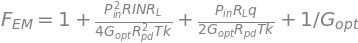

In [4]:
### External modulated noise figure equation
sym.Eq(F_EM,1+1/Gopt+(q*Pin*RL)/(2*Gopt*Rpd*k*T)+(RIN*Pin**2*RL)/(4*Gopt*Rpd**2*k*T))

In [5]:
### Directly Modulated Link Loss
sym.Eq(G_DM, (1/4)*Sld**2*Gopt**2*Rpd**2)

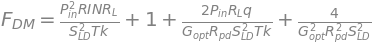

In [6]:
### Directly Modulated Noise Figure
sym.Eq(F_DM, 1+4/(Sld*Gopt*Rpd)**2+(2*q*Pin*RL)/(Sld**2*Gopt*Rpd*k*T)+(RIN*Pin**2*RL)/(Sld**2*k*T))

In [7]:
# function that returns dP/dz for nonlinear loss
from scipy.integrate import odeint
def model(P,z):
    alpha1TE = 1.04 #   db/cm Linear Loss from AMF review paper
    alpha2TE = 32.6 #   db/cm/W from #
    alpha3TE = 2.04e3 # db/cm/W^2 from #
    dPdz = -alpha1TE * P - alpha2TE * P**2 - alpha3TE * P**3
    return dPdz


def compute_nonlinear_gain(wg_length, Pin_lin_wg, model, ODEres=1000):
    """
    Compute nonlinear optical gain (in dB) along a waveguide
    by solving an ODE for each input power.
    Parameters
    ----------
    wg_length : Waveguide length #cm
    Pin_lin_wg? : Array Input optical powers (linear scale, e.g. Watts).
    model : ODE function of the form model(P, z).
    ODEres : Number of spatial discretization points.
    Return
    ------
    Gopt_nonlin : ndarray
        Optical nonlinear gain in dB for each input power.
    """

    Wgz = np.linspace(0, wg_length, ODEres)
    Pin_lin_wg = np.asarray(Pin_lin_wg)

    Gopt_nonlin = np.zeros(len(Pin_lin_wg))

    for i, y0 in enumerate(Pin_lin_wg):

        Pin_z = odeint(model, y0, Wgz)

        P_in = Pin_z[0][0]
        P_out = Pin_z[-1][0]

        if P_in <= 0 or P_out <= 0:
            Gopt_nonlin[i] = -np.inf
        else:
            Gopt_nonlin[i] = 10 * np.log10(P_out / P_in)

    return Gopt_nonlin



def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

def db_to_lin(db):
    return 10**(db / 10)

def lin_to_db(linear):
    linear = np.asarray(linear)
    if np.any(linear <= 0):
        raise ValueError("Power ratio must be > 0 to convert to dB.")
    return 10 * np.log10(linear)

def mw_to_dbm(mw):
    mw = np.asarray(mw)
    if np.any(mw <= 0):
        raise ValueError("Power in mW must be > 0 to convert to dBm.")
    return 10 * np.log10(mw)


def dbm_to_w(dbm):
    return 10**((np.asarray(dbm) - 30) / 10)
    
def dbm_to_mw(dbm):
    dbm = np.asarray(dbm)
    return 10**(dbm / 10)

In [8]:
def best_metrics(name, Pin_axis, G_no_lna, NF_no_lna, G_lna=None, NF_lna=None):
    """
    Returns best link gain/loss and best NF for one architecture.

    Best link gain/loss:
        max(G) in dB, because higher gain means lower effective loss.

    Best NF:
        min(NF) in dB.
    """

    Pin_axis = np.asarray(Pin_axis).squeeze()
    G_no_lna = np.asarray(G_no_lna).squeeze()
    NF_no_lna = np.asarray(NF_no_lna).squeeze()

    idx_best_G_no_lna = np.nanargmax(G_no_lna)
    idx_best_NF_no_lna = np.nanargmin(NF_no_lna)

    row = {
        "Architecture": name,

        "Best Gain No LNA (dB)": G_no_lna[idx_best_G_no_lna],
        "Pin at Best Gain No LNA (dBm)": Pin_axis[idx_best_G_no_lna],
        "Best NF No LNA (dB)": NF_no_lna[idx_best_NF_no_lna],
        "Pin at Best NF No LNA (dBm)": Pin_axis[idx_best_NF_no_lna],
    }

    if G_lna is not None and NF_lna is not None:
        G_lna = np.asarray(G_lna).squeeze()
        NF_lna = np.asarray(NF_lna).squeeze()

        idx_best_G_lna = np.nanargmax(G_lna)
        idx_best_NF_lna = np.nanargmin(NF_lna)

        row.update({
            "Best Gain With LNA (dB)": G_lna[idx_best_G_lna],
            "Pin at Best Gain With LNA (dBm)": Pin_axis[idx_best_G_lna],
            "Best NF With LNA (dB)": NF_lna[idx_best_NF_lna],
            "Pin at Best NF With LNA (dBm)": Pin_axis[idx_best_NF_lna],
        })

    return row

In [9]:
def summarize_gain_nf_no_pin(
    architecture,
    G,
    NF,
    G_LNA,
    NF_LNA,
    gain_mode="max"
):
    """
    Summarize best gain/loss and NF for one architecture without reporting Pin.

    Parameters
    ----------
    architecture : str
        Name of modulation architecture.

    G : array-like
        Link gain/loss in dB without LNA.

    NF : array-like
        Noise figure in dB without LNA.

    G_LNA : array-like
        Link gain/loss in dB with LNA.

    NF_LNA : array-like
        Noise figure in dB with LNA.

    gain_mode : str
        "max" means best gain is max(G), appropriate if G is link gain in dB.
        "min" means best loss is min(G), appropriate if G is plotted as positive loss.

    Returns
    -------
    dict
        One summary row.
    """

    G = np.asarray(G).squeeze()
    NF = np.asarray(NF).squeeze()
    G_LNA = np.asarray(G_LNA).squeeze()
    NF_LNA = np.asarray(NF_LNA).squeeze()

    if gain_mode == "max":
        best_G = np.nanmax(G)
        best_G_LNA = np.nanmax(G_LNA)
    elif gain_mode == "min":
        best_G = np.nanmin(G)
        best_G_LNA = np.nanmin(G_LNA)
    else:
        raise ValueError("gain_mode must be either 'max' or 'min'")

    return {
        "Architecture": architecture,
        "Best G No LNA (dB)": best_G,
        "Best NF No LNA (dB)": np.nanmin(NF),
        "Best G With LNA (dB)": best_G_LNA,
        "Best NF With LNA (dB)": np.nanmin(NF_LNA),
    }

In [10]:
# Formatting and Housekeeping
fs=16
isSaving = True
place_text = True
dpi_res = 300 
color = plt.cm.magma(np.linspace(0.175, 0.85, 5))
x_axis_res = 31
line_EM = "-"
line_DM = "--"
line_EM_LNA = ":"
line_DM_LNA = "-."
# color_BalHy = colors[3]

color_EM = color[0]
color_DM = 'k'


label_DM = 'Direct Modulation'
label_EM = 'External Modulation'
label_LNA = ' w/ LNA'
label_Si = 'Silicon '
outputFile = ''

line_w = 2.5
dot_size = 10

In [11]:
# Experimental Data - MRR weight and MRR nonlinear mod
fname = './08-27-2025_all_data_single_neuron_feedback.pkl'
with open(fname, 'rb') as file:
    all_data = pickle.load(file)
    # print(all_data.keys())

In [12]:
### Couple Input Layer Architectural Options
### Laser -> Modulation -> Fanout -> MRR Weight Bank -> BPD -> Nonlinear Mod -> ...
### Sources: DFB Laser, InP Laser, DML Laser (3) 
### Modulation: Direct Mod, SiPh MRR modulator, SiPh MZM, External LiNo MZM (4)


In [13]:
# Parameter Definition 
q = 1.6e-19
k = 1.38e-23
T = 290 #K
RL = 50 #Ohms
RF_BW = 10e9 # Minimal BW
ODEres = 31 # Resolution of ODE Calculation 

# Note: All Linear Modulators Biased at operating point = quadrature 

########## Input Layer
##### Sources
# Off-Chip Laser
# https://www.thorlabs.com/low-noise-narrow-linewidth-laser-systems-1550-nm/?utm_source=chatgpt.com&tabName=Overview
# DFB15TK Turnkey Low-Noise DFB Laser System, 1550 nm, 100 mW, PM Fiber, FC/APC, -160 RIN @ 1 GHz, 7k USD
RIN = -160 #dB / Hz
RIN_lin = 10**(RIN/10) #/Hz
Pin_max_DFB = 120#mW
Pin_max_lin = 150 #mW
Pin_max = 10*np.log10(Pin_max_lin) # mW to dBm 
Pin = np.linspace(0,Pin_max,x_axis_res) #dBm
Pin_lin = 10**(Pin/10)/1000 #W

# InP Laser
# https://www.hhi.fraunhofer.de/fileadmin/PDF/PC/LAS/High_Power_InP_DFB_Laser_V2a.pdf
RIN_InP = -155 #dB / Hz
RIN_InP_lin = 10**(RIN_InP/10) #/Hz
Pin_max_InP_lin = 100 #mW
Pin_max_InP = 20 #dBm
Pin_InP = np.linspace(0,Pin_max_InP,x_axis_res) #dBm
Pin_InP_lin = 10**(Pin_InP/10)/1000 #W

# DML Laser
# https://www.cybel-llc.com/wp-content/uploads/2018/07/DM-DFB-Laser_030818a-v1.pdf
RIN_DML = -162.8 #dB / Hz 
RIN_DML_lin = 10**(RIN_DML/10) #/Hz
Pin_max_DML_lin = 70 #mW
Pin_max_DML = 10*np.log10(Pin_max_DML_lin) # mW to dBm 
Pin_DML = np.linspace(0,Pin_max_DML,x_axis_res) #dBm
Pin_DML_lin = 10**(Pin_DML/10)/1000 #W

##### SiPh Coupler Loss 
# https://www.advmf.com/wp-content/uploads/2019/08/AMF-Brochure-Web.pdf
# Siew, Shawn Yohanes, et al. "Review of silicon photonics technology and platform development." Journal of Lightwave Technology 39.13 (2021): 4374-4389.
# Vertical grating coupler (PDK realistic)
VCoupler = -4      # dB per coupler
# Edge coupler (inverse taper)
ECoupler = -1.2    # dB per facet


##### Fanout
# Siew, Shawn Yohanes, et al. "Review of silicon photonics technology and platform development." Journal of Lightwave Technology 39.13 (2021): 4374-4389.
Fanout = 2  # number of outputs (equal power to each neuron)
# per-stage excess loss for a 1x2 splitter (dB) — typical 0.2–0.5 dB in PDKs; use 0.3 dB as conservative
Splitter_excess_per_stage_dB = 0.3
# compute number of 1x2 stages needed for given Fanout (assumes Fanout is power of 2)
stages = int(np.ceil(np.log2(Fanout)))
total_excess_dB = Splitter_excess_per_stage_dB * stages
# ideal splitting loss (dB)
ideal_split_loss_dB = -10 * np.log10(1.0 / Fanout)
# total fanout loss (dB) = ideal + excess
Fanout_Loss = -(ideal_split_loss_dB + total_excess_dB)
# print(Fanout_Loss)

##### Modulation Options

# Direct Mod - COTS (1) 
# https://www.cybel-llc.com/wp-content/uploads/2018/07/DM-DFB-Laser_030818a-v1.pdf
S_LD = 0.35263 # mW/mA
Tmod_DML = 0 # dB
#Typical from Charles Cox / ILX /
# http://www.cybel-llc.com/wp-content/uploads/2018/07/DM-DFB-Laser_030818a-v1.pdf


# External LiNo Mod - COTS (2)
# https://www.eospace.com/40-gb/s-modulators
Tmod_LiNo = -3 #dB 
Tmod_LiNo_lin = 10**(Tmod_LiNo/10)
Vpi_LiNo = 3.5 #V

# External TFLN Mod - COTS (3)
# Meng, Xiangyu, et al. "Thin‐film lithium niobate modulators with ultra‐high modulation efficiency." Laser & Photonics Reviews 19.1 (2025): 2400809.
Tmod_TFLN = -2.9 #dB 
Tmod_TFLN_lin = 10**(Tmod_TFLN/10)
Vpi_TFLN_pcm = 1.02 #V / cm
Vpi_TFLN_len = 0.5 #cm
Vpi_TFLN = Vpi_TFLN_pcm/Vpi_TFLN_len # 2.04

# SiPh MRR Modulator (4)
# Reed, Graham T., et al. "Silicon optical modulators." Nature photonics 4.8 (2010): 518-526.
# Xiao, Xi, et al. "44-Gb/s silicon microring modulators based on zigzag PN junctions." IEEE Photonics Technology Letters 24.19 (2012): 1712-1714.
# Zhao, Shiao, et al. "High modulation efficiency micro-ring modulator with low driving voltage for high speed optical interconnection." Optics Express 33.9 (2025): 19442-19452.
# Vpi in an MRR structure is pretty meaningless, what you need is the V_linewdith
lam_nm = 1550.0
Q_loaded = 5200.0
dlam_pm_per_V = 33.5

dlam_pm = (lam_nm / Q_loaded) * 1e3   # pm
V_linewidth = dlam_pm / dlam_pm_per_V # V

# print("Linewidth (pm):", dlam_pm)
# print("V_linewidth (V):", V_linewidth)
# print("0.15 linewidth Vpp (V):", 0.15*V_linewidth)

# FWHM
Vpi_MRRMod = 0.5*V_linewidth #4.448
# Realistic operating conditions are about 15% of linewidth
Vpi_Drive = 0.15*V_linewidth #1.334
print(Vpi_MRRMod, Vpi_Drive)

Tmod_MRRMod =  -3  #dB 
Tmod_MRRMod_lin = 10**(Tmod_MRRMod/10)


# SiPh MZM Modulator (5) 
# Siew, Shawn Yohanes, et al. "Review of silicon photonics technology and platform development." Journal of Lightwave Technology 39.13 (2021): 4374-4389.
Tmod_MZMMod = -4 #dB 
Tmod_MZMMod_lin = 10**(Tmod_MZMMod/10)
Vpi_MZMMod = 6.29 #V

# BTO
#cite: Eltes, Felix, et al. "A BaTiO 3-based electro-optic Pockels modulator monolithically integrated on an advanced silicon photonics platform." Journal of Lightwave Technology 37.5 (2019): 1456-1462.
BTO_Losspercm = 5.8 #dB/cm
BTO_Vpipercm = 0.23 #Vpi/cm
BTO_length = 0.2 #cm 
Tmod_BTO = -(BTO_Losspercm*BTO_length) # 1.16 dB 
Tmod_BTO_lin = 10**(Tmod_BTO/10)
Vpi_BTO = BTO_Vpipercm/BTO_length # 1.15 V

###### Waveguide Propoerties
wg_length = .05 #cm

###### MRR Properties
# Reference: Prucnal, Paul R., and Bhavin J. Shastri. Neuromorphic photonics. CRC press, 2017.
# Nonlinear Loss Calculated BSS Paper / cite Weipeng
# Zhang, Weipeng, et al. "A system-on-chip microwave photonic processor solves dynamic RF interference in real time with picosecond latency." Light: Science & Applications 13.1 (2024): 14.
# Assumptions for derived scaling:
lambda_nm = 1550
Cband_nm   = 35
FSR_nm     = 10        # ~10 µm radius ring 
k_spacing  = 4         # channel spacing = k * linewidth
IL_mrr = -0.5 # typical excess loss in rnage

# Derived relations:
# linewidth_nm = lambda0_nm / Q
# channel_spacing_nm = k_spacing * linewidth_nm
# N_channels ≈ Cband_nm / channel_spacing_nm
# finesse F = FSR_nm / linewidth_nm
# buildup B ≈ F / pi
#                            Quality Factor       Build Up Factor    Channel Capacity (C-Band)
# High-speed modulation:          10,000                30                     56
# WDM filtering / weighting:      20,000                50                     113
# Narrowband filtering:    	      50,000               100                     282
# Trade off between channel density, sensitivty to thermal drift, phase sensitivity, and larger nonlinear effects
# Typical buildup factor ≈ 20–40

#Typical WDM weight bank
# From Tait et al., JSTQE 2016 (Microring Weight Banks)
MRR_Q  = 11070          # measured (8-ch example)
MRR_BU = 17.3           # derived from finesse 133: B ≈ F/pi
# from https://arxiv.org/pdf/1507.00686.pdf
# Typical Build up = 17.3
# Multiply incoming light by that intensity over length of ring
# Nik BSS rings are radii 22 μm 
r_bssmrr = 15*1e-4
c_bssmrr = 2*np.pi*r_bssmrr


###### On-Chip BPD
# Hai, Mohammed Shafiqul, Meer Nazmus Sakib, and Odile Liboiron-Ladouceur. "A 16 GHz silicon-based monolithic balanced photodetector with on-chip capacitors for 25 Gbaud front-end receivers." Optics express 21.26 (2013): 32680-32689.
# N. M. Fahrenkopf, C. McDonough, G. L. Leake, Z. Su, E. Timurdogan, and D. D. Coolbaugh, “The AIM photonics MPW: 
# A highly accessible cutting edge technology for rapid prototyping of photonic integrated circuits,” IEEE J. Sel. Topics Quantum Electron., vol. 25, no. 5, pp. 1–6, Sep. 2019.
BW_pd = 50 # GHz 
Rpd_Int = 1 #A/W
ID = 40 #nA

# Using IP3 = 35 at 150 mA calculate c
IP3_ref = 35
ID_ref = 150e-3 
c = ((2*S_LD)*10**(IP3_ref/10))/((150e-3/Rpd_Int)**2*RL) 

4.448909299655568 1.3346727898966704


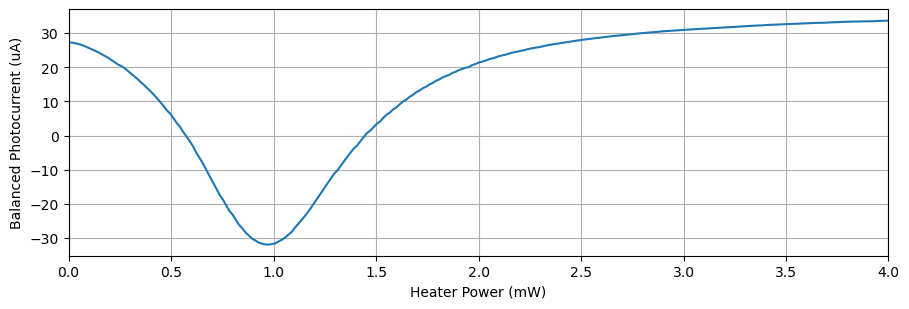

In [14]:
# Linear Weight
weight_heater_powers = np.linspace(0, 4, 251)
pdp_currents_N1w2 = all_data['pdp_currents_N1w2'] # positive photodiode currents (nA)
pdm_currents_N1w2 = all_data['pdm_currents_N1w2'] # negative photodiode currents (nA)
balanced_photocurrents_N1w2 = (np.abs(pdm_currents_N1w2) - np.abs(pdp_currents_N1w2) )*1e6

plt.figure(figsize=[9, 3])
plt.grid('true')
plt.plot(weight_heater_powers, balanced_photocurrents_N1w2)
plt.xlim(0,4)
plt.tight_layout()
plt.xlabel("Heater Power (mW)")
plt.ylabel("Balanced Photocurrent (uA)")
plt.show()

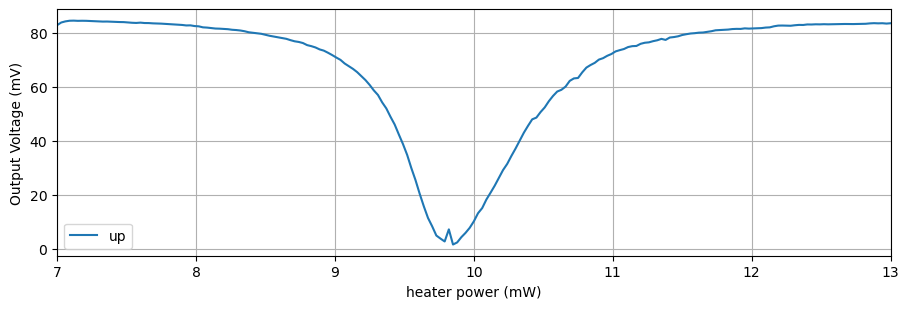

In [15]:
mod_heater_powers = all_data['mod_heater_powers']
output_voltage_up_N1 = all_data['output_voltage_up_N1']
output_voltage_down_N1 = all_data['output_voltage_down_N1']
weights_sweep_arr_w2 = all_data['weights_sweep_arr_w2']
mod_curr_arr_weight_sweep_N1 = all_data['mod_curr_arr_weight_sweep_N1']
neuron_output_volt_arr_weight_sweep_N1 = all_data['neuron_output_volt_arr_weight_sweep_N1']

# neuron output versus modulator heater power . Modulator heater is biased at 9.87 and the PN junction is biased at 2.45 V
plt.figure(figsize=[9, 3])
plt.grid('true')
plt.plot(mod_heater_powers, output_voltage_up_N1*1000, '-', label='up')
# plt.axvline(x=9.87, color='red', linestyle=':')
plt.xlim(7,13)
plt.tight_layout()
plt.xlabel("heater power (mW)")
plt.ylabel("Output Voltage (mV)")
plt.legend()
plt.show()

In [16]:
###### TIA Gain Term (Optional) 
# Okamoto, Daisuke, et al. "A 25-Gb/s 5× 5 mm^ 2 Chip-Scale Silicon-Photonic Receiver Integrated With 28-nm CMOS Transimpedance Amplifier." Journal of Lightwave Technology 34.12 (2016): 2988-2995.
TIA_ZT = 82 # dB*Ohm
TIA_ZT_lin = 10**(TIA_ZT/20)
G_TIA = 20*np.log10(TIA_ZT_lin/RL)

In [17]:
###### LNA Options
## https://www.rflambda.com/pdf/lownoiseamplifier/RLNA00M65GD.pdf
# LNA_G = 19.5 #dB
# LNA_NF = 4.5 #dB
# LNA_G_lin = 10**(LNA_G/10)
# LNA_NF_lin = 10**(LNA_NF/10)

## https://www.rflambda.com/pdf/lownoiseamplifier/RLNA05M54GA.pdf
LNA_G = 23 #dB
LNA_NF = 4 #dB
LNA_G_lin = 10**(LNA_G/10)
LNA_NF_lin = 10**(LNA_NF/10)

In [18]:
# Optical Power into the waveguide for different Architectures
# Logrithmic
Pin_wg_DML = Pin_DML + ECoupler
Pin_wg_LiNo = Pin + ECoupler + Tmod_LiNo
Pin_wg_TFLN = Pin + ECoupler + Tmod_TFLN
Pin_wg_MRRMod = Pin + ECoupler + Tmod_MRRMod
Pin_wg_MRRModNL = Pin + ECoupler + Tmod_MRRMod
Pin_wg_MZMMod = Pin + ECoupler + Tmod_MZMMod
Pin_wg_BTO = Pin + ECoupler + Tmod_BTO

# Linear
Pin_lin_wg_DML = dbm_to_w(Pin_wg_DML)
Pin_lin_wg_LiNo =  dbm_to_w(Pin_wg_LiNo)
Pin_lin_wg_TFLN = dbm_to_w(Pin_wg_TFLN)
Pin_lin_wg_MRRMod = dbm_to_w(Pin_wg_MRRMod)
Pin_lin_wg_MRRModNL = dbm_to_w(Pin_wg_MRRMod)
Pin_lin_wg_MZMMod = dbm_to_w(Pin_wg_MZMMod)
Pin_lin_wg_BTO = dbm_to_w(Pin_wg_BTO)




# Si Ph RF Anaylsis

### Nonlinearity in Silicon Waveguide

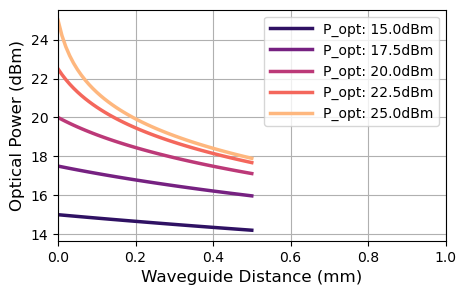

In [19]:
# Nonlinearities in Silicon Waveguide
# Tokushima, Masatoshi, Jun Ushida, and Takahiro Nakamura. "Nonlinear loss characterization 
# of continuous wave guiding in silicon wire waveguides." Applied Physics Express 14.12 (2021):
# 122008.

# 350 nm (H) × 200 nm (V ). The upper cladding was
# a 2 μm thick silicon dioxide layer,

BetaTPA = 24.8 #cm/GW
# Strongly optimized for TE₀ mode.
# TE
alpha1TE = 1.04 #   db/cm Linear Loss from AMF review paper
alpha2TE = 32.6 #   db/cm/W
alpha3TE = 2.04e3 # db/cm/W^2

# # TM
# alpha1TM = 3.72 #   db/cm Linear Loss 
# alpha2TM = 1.45 #   db/cm/W
# alpha3TM = 4.72e2 # db/cm/W^2


WgL = wg_length # .1 cm / 1 mm
Pin_nl = np.linspace(15,25,5)
Pin_lin_nl = 10**(Pin_nl/10)/1000

# distance points points
Wgz = np.linspace(0,wg_length,51) #Waveguide distance

# initial condition
# y0 = .02 #W

#Nonlinear loss|
NL_loss = np.zeros((len(Pin_nl),1))

plt.figure(figsize=(5,3))
i=0
for y0 in Pin_lin_nl:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    NL_loss[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    plt.plot(Wgz*10,10*np.log10(Pin_z/1e-3), color= color[i], linewidth=line_w, label = 'P_opt: '+ str(Pin_nl[i])+ 'dBm')
    i+=1
plt.xlabel('Waveguide Distance (mm)', fontsize=12)
plt.ylabel('Optical Power (dBm)', fontsize=12)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.xlim(0,1)
plt.show()

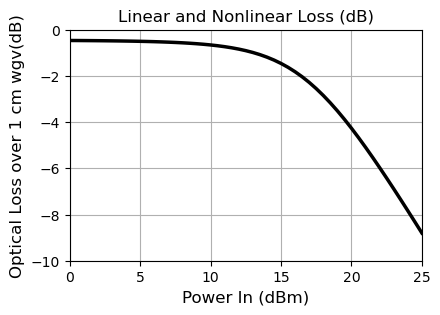

In [20]:
fig = plt.figure(figsize=(10, 3))
Pin_nl = np.linspace(15,25,5)
Pin_lin_nl = 10**(Pin_nl/10)/1000

# distance points points
Wgz = np.linspace(0,0.1,31) #Waveguide distance

# initial condition
# y0 = .02 #W

#Nonlinear loss|
NL_loss = np.zeros((len(Pin_nl),1))

i=0
for y0 in Pin_lin_nl:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    NL_loss[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    i+=1
# plt.xlabel('Waveguide Distance (mm)', fontsize=12)
# plt.ylabel('Optical Power (dBm)', fontsize=12)
# plt.grid(which='major', axis='both')
# plt.legend(handlelength=3, loc='best')
# plt.xlim(0,1)
WgL = 0.1 # cm / 10 mm
Pin_nl = np.linspace(0,25,51)
Pin_lin_nl = 10**(Pin_nl/10)/1000

# distance points points
Wgz = np.linspace(0,WgL,31) #Waveguide distance


#Nonlinear loss|
NL_loss = np.zeros((len(Pin_nl),1))

i=0
for y0 in Pin_lin_nl:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    NL_loss[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    i+=1


plt.subplot(1, 2, 2)
plt.plot(Pin_nl,NL_loss, color = 'k', linewidth = line_w)
plt.xlabel('Power In (dBm)', fontsize=12)
plt.title('Linear and Nonlinear Loss (dB)', fontsize=12)
plt.ylabel('Optical Loss over 1 cm wgv(dB)', fontsize=12)
plt.xlim(0,25)
plt.ylim(-10,0)
plt.grid(which='major', axis='both')
plt.show()

### Nonlinear loss of resonator

/var/folders/07/gr2d381s6qd7z37r9vj0qgl80008nl/T/ipykernel_73579/1179274563.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Gopt_nonlin_mrr[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])


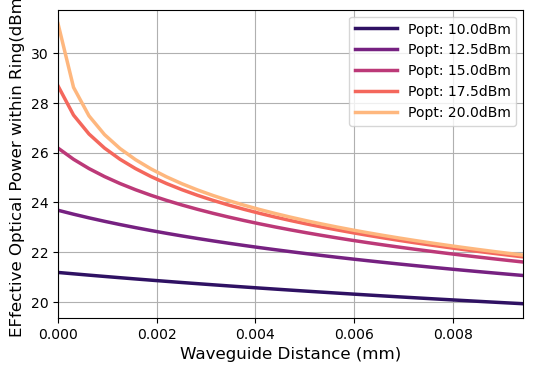

In [21]:
####### Nonlinear MRR Loss 
Pin_nl = np.linspace(10,20,5)
WgL = wg_length
Pin_lin_wg_mrr = (10**((Pin_nl+ECoupler)/10)/1000)*MRR_BU
# distance points points
WgL = c_bssmrr # cm
# distance points points
Wgz = np.linspace(0,WgL,31) #Waveguide distance


#Nonlinear loss
Gopt_nonlin_mrr = np.linspace(0,0,len(Pin_nl))

plt.figure(figsize=(6,4))
i=0
for y0 in Pin_lin_wg_mrr:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    Gopt_nonlin_mrr[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    plt.plot(Wgz,10*np.log10(Pin_z/1e-3), color= color[i], linewidth=line_w, label = 'Popt: '+ str(Pin_nl[i])+ 'dBm')
    # print(np.max(10*np.log10(Pin_z/1e-3)))
    i+=1
plt.xlabel('Waveguide Distance (mm)', fontsize=12)
plt.ylabel('EFfective Optical Power within Ring(dBm)', fontsize=12)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.xlim(0,WgL)
plt.show()



/var/folders/07/gr2d381s6qd7z37r9vj0qgl80008nl/T/ipykernel_73579/597960062.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Gopt_nonlin_mrr[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])


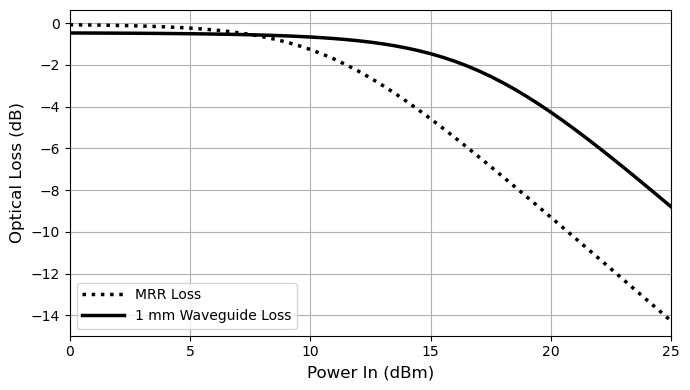

In [22]:
fig = plt.figure(figsize=(7,4))

Pin_nl = np.linspace(10,20,5)
WgL = 0.1 # cm / 10 mm
Pin_lin_wg_mrr = (10**((Pin_nl+ECoupler)/10)/1000)*MRR_BU
# distance points points
WgL = c_bssmrr # cm
# distance points points
Wgz = np.linspace(0,WgL,31) #Waveguide distance


#Nonlinear loss
Gopt_nonlin_mrr = np.linspace(0,0,len(Pin_nl))

i=0
for y0 in Pin_lin_wg_mrr:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    Gopt_nonlin_mrr[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    # plt.plot(Wgz,10*np.log10(Pin_z/1e-3), color= color[i], linewidth=line_w, label = 'Popt: '+ str(Pin_nl[i])+ 'dBm')
    i+=1
# plt.xlabel('Waveguide Distance (mm)', fontsize=12)
# plt.ylabel('Optical Power within Ring(dBm)', fontsize=12)
# plt.grid(which='major', axis='both')
# plt.legend(handlelength=3, loc='best')
# plt.xlim(0,WgL)

WgL = 0.1 # cm / 10 mm
Pin_nl = np.linspace(0,25,51)
Pin_lin_nl = 10**(Pin_nl/10)/1000

# distance points points
Wgz = np.linspace(0,WgL,31) #Waveguide distance


#Nonlinear loss|
NL_loss = np.zeros((len(Pin_nl),1))

i=0
for y0 in Pin_lin_nl:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    NL_loss[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    i+=1


### MRR
Pin_nl = np.linspace(0,25,51)
Pin_lin_wg_mrr = (10**((Pin_nl+ECoupler)/10)/1000)*MRR_BU

# distance points points
WgL = c_bssmrr # cm
Wgz = np.linspace(0,WgL,31) #Waveguide distance


#Nonlinear loss|
Gopt_nonlin_mrr = np.zeros((len(Pin_nl),1))

i=0
for y0 in Pin_lin_wg_mrr:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    Gopt_nonlin_mrr[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    i+=1

plt.plot(Pin_nl,Gopt_nonlin_mrr, color = 'k', linestyle=':',linewidth = line_w, label = 'MRR Loss')
plt.plot(Pin_nl,NL_loss, color = 'k', linewidth = line_w, label = '1 mm Waveguide Loss')
plt.xlabel('Power In (dBm)', fontsize=12)
plt.ylabel('Optical Loss (dB)', fontsize=12)
plt.xlim(0,25)
plt.legend(handlelength=3, loc='best')
# plt.ylim(-10,0)
plt.grid(which='major', axis='both')
plt.tight_layout()
plt.show()

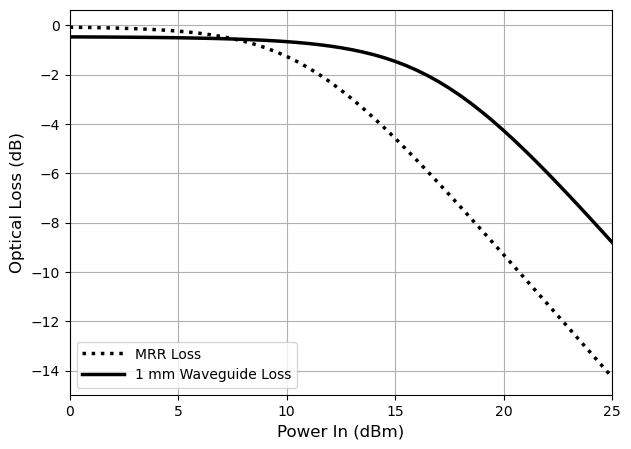

In [23]:
WgL = 0.1 # cm / 10 mm
Pin_nl = np.linspace(0,25,51)
Pin_lin_nl = 10**(Pin_nl/10)/1000

# distance points points
Wgz = np.linspace(0,WgL,31) #Waveguide distance

#Nonlinear loss|
NL_loss = np.zeros((len(Pin_nl),1))

i=0
for y0 in Pin_lin_nl:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    NL_loss[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    i+=1



### MRR
Pin_nl = np.linspace(0,25,51)
Pin_lin_wg_mrr = (10**((Pin_nl+ECoupler)/10)/1000)*MRR_BU

# distance points points
WgL = c_bssmrr # cm
Wgz = np.linspace(0,WgL,31) #Waveguide distance


#Nonlinear loss|
Gopt_nonlin_mrr = np.zeros((len(Pin_nl),1))

i=0
for y0 in Pin_lin_wg_mrr:
    # solve ODE
    Pin_z = odeint(model,y0,Wgz)
    Gopt_nonlin_mrr[i] = 10*np.log10(Pin_z[-1]/Pin_z[0])
    # plot results
    i+=1

plt.figure(figsize=(7,5))
plt.plot(Pin_nl,Gopt_nonlin_mrr, color = 'k', linestyle=':',linewidth = line_w, label = 'MRR Loss')
plt.plot(Pin_nl,NL_loss, color = 'k', linewidth = line_w, label = '1 mm Waveguide Loss')
plt.xlabel('Power In (dBm)', fontsize=12)
plt.ylabel('Optical Loss (dB)', fontsize=12)
plt.xlim(0,25)
plt.legend(handlelength=3, loc='best')
# plt.ylim(-10,0)
plt.grid(which='major', axis='both')
plt.show()

### 5 Case - RF Link Analysis - Linear Front-end

In [24]:
# LNA Definition
# Marki ADM-10715PSM
# BW: 0.1-22 GHz
G_LNA_dB = 25.7    # dB
NF_LNA_dB = 1.8     # dB

G_LNA_lin = db_to_lin(G_LNA_dB)
F_LNA_lin = db_to_lin(NF_LNA_dB)

### Direct Modulated

In [25]:
G_DM = np.zeros((1,len(Pin)))
G_DM_lin = np.zeros((1,len(Pin)))
NF_DM = np.zeros((1,len(Pin)))
F_DM_lin = np.zeros((1,len(Pin)))

##############
#Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_DML,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_DML_mrr = db_to_lin(lin_to_db(Pin_lin_wg_DML)+Fanout_Loss)

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_DML_mrr*MRR_BU,
    model=model,
    ODEres=ODEres
)
    
# Total Optical Loss

Gopt = Gopt_nonlin_wg+Gopt_nonlin_mrr+IL_mrr+Fanout_Loss #dB
Gopt_lin = db_to_lin(Gopt)

# DML link gain
G_DM_lin = (1/4) * (S_LD**2) * (Gopt_lin**2) * (Rpd_Int**2)
G_DM     = lin_to_db(G_DM_lin)

# --- PD power/current for noise ---
P_PD = Pin_DML_lin * Gopt_lin
I_PD = Rpd_Int * P_PD
# I_PD = Rpd_Int * Pin * Gopt

# --- Noise factor
F_DM_lin = 1 + (
    4 / ((S_LD * Gopt_lin * Rpd_Int)**2)
    + (2*q*I_PD*RL) / (((S_LD * Gopt_lin * Rpd_Int)**2) * k*T)
    + (RIN_DML_lin * (I_PD**2) * RL) / (((S_LD * Gopt_lin * Rpd_Int)**2) * k*T)
)
NF_DM = lin_to_db(F_DM_lin)

# Friis cascaded NF: LNA -> DML photonic link
F_DM_LNA_lin = F_LNA_lin + (F_DM_lin - 1) / G_LNA_lin
NF_DM_LNA = lin_to_db(F_DM_LNA_lin)

# Total RF gain for DML + LNA
G_DM_LNA_lin = G_LNA_lin * G_DM_lin
G_DM_LNA = lin_to_db(G_DM_LNA_lin)


# SFDR for DML
DML_IIP3 = lin_to_db((c*Pin_DML_lin**2*RL)/(2*S_LD))
SFDR_3DML = (2/3)*(DML_IIP3 - NF_DM + 174 ) 

# Refer DML IIP3 back to antenna/LNA input
DML_IIP3_referred_to_antenna = DML_IIP3 - G_LNA_dB

# SFDR for DML with LNA, referred to antenna input
SFDR_3DML_LNA = (2/3) * (
    DML_IIP3_referred_to_antenna - NF_DM_LNA + 174
)


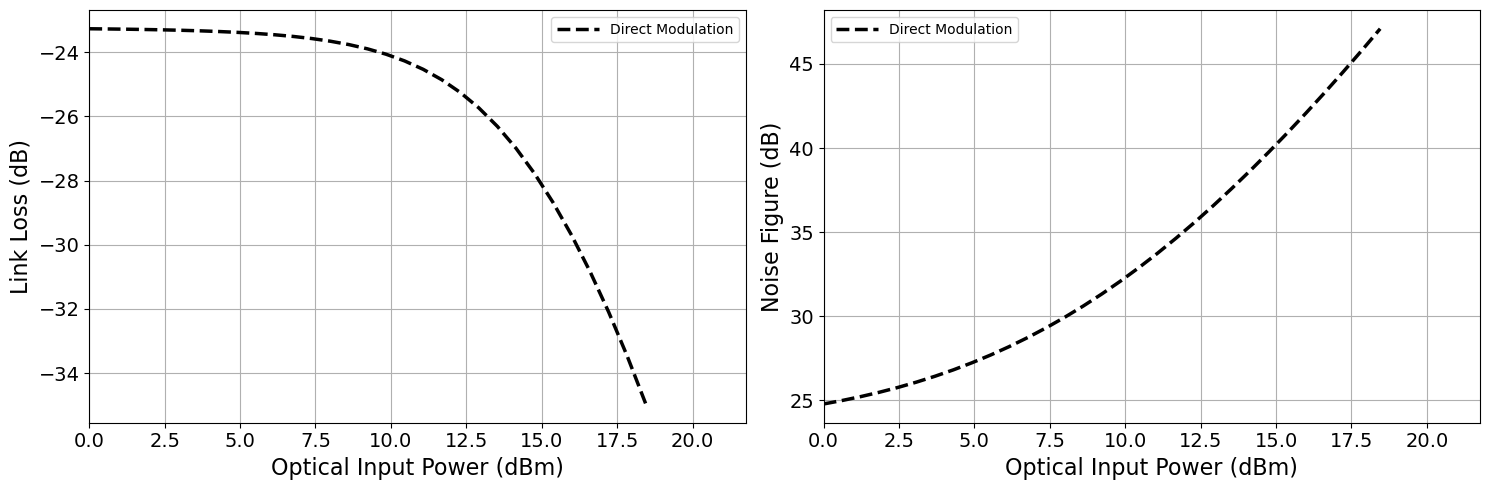

In [26]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(Pin_DML, np.squeeze(G_DM), color=color_DM, linewidth=line_w, label=label_DM, linestyle=line_DM)
plt.ylabel('Link Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(30
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.subplot(1, 2, 2)
plt.plot(Pin_DML,NF_DM, color =color_DM,linewidth=line_w,label=label_DM, linestyle = line_DM)
plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(20,70)
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.tight_layout()
plt.show()

##### Although you are gaining from increasing optical power the nonlinear losses grow faster than the square increase in gain,
# P^2 and P^3, noise will stagnate becuase it is relative, and the power at the PD is actually not increasing significantly

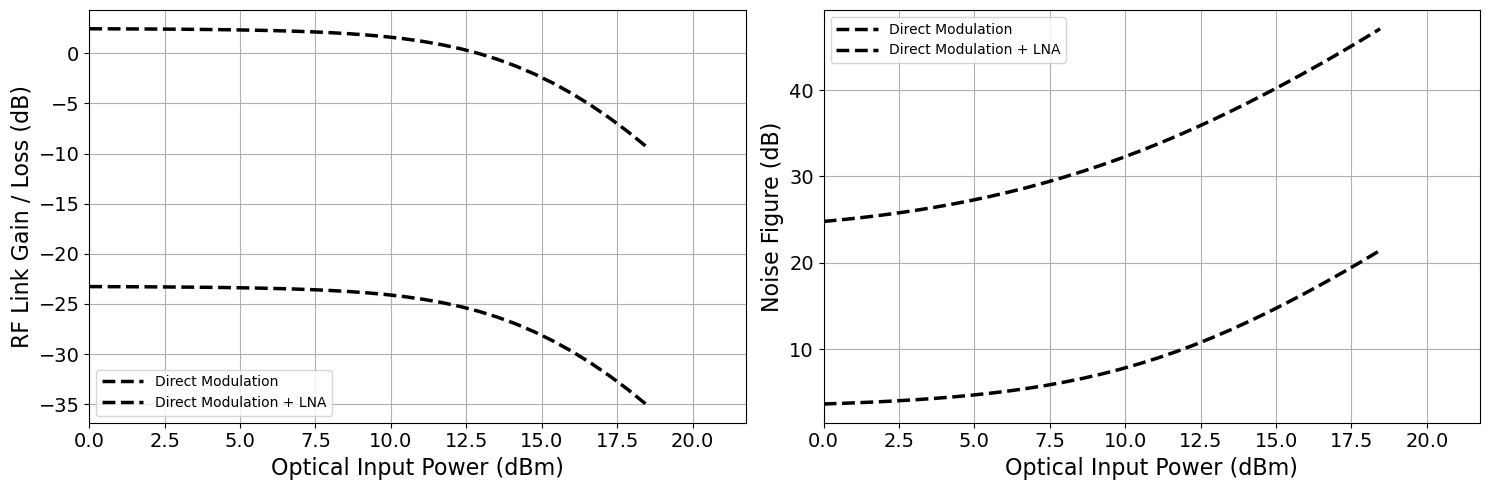

In [27]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

# Original DML link
plt.plot(
    Pin_DML,
    np.squeeze(G_DM),
    color=color_DM,
    linewidth=line_w,
    label=label_DM,
    linestyle=line_DM
)

# DML link with LNA
plt.plot(
    Pin_DML,
    np.squeeze(G_DM_LNA),
    color=color_DM,
    linewidth=line_w,
    label=label_DM + ' + LNA',
    linestyle='--'
)

plt.ylabel('RF Link Gain / Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')


plt.subplot(1, 2, 2)

# Original DML noise figure
plt.plot(
    Pin_DML,
    np.squeeze(NF_DM),
    color=color_DM,
    linewidth=line_w,
    label=label_DM,
    linestyle=line_DM
)

# DML noise figure with LNA using Friis
plt.plot(
    Pin_DML,
    np.squeeze(NF_DM_LNA),
    color=color_DM,
    linewidth=line_w,
    label=label_DM + ' + LNA',
    linestyle='--'
)

plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')

plt.tight_layout()
plt.show()

### LiNo Off-Chip Modulator

In [28]:
G_EM_LiNo = np.zeros((1,len(Pin)))
G_EM_lin_LiNo = np.zeros((1,len(Pin)))
NF_EM_LiNo = np.zeros((1,len(Pin)))
NF_EM_lin_LiNo = np.zeros((1,len(Pin)))
SFDR3_LiNo = np.zeros((1,len(Pin)))
SFDR3_lin_LiNo = np.zeros((1,len(Pin)))

# LNA-included quantities
G_EM_LiNo_LNA = np.zeros((1,len(Pin)))
G_EM_lin_LiNo_LNA = np.zeros((1,len(Pin)))
NF_EM_LiNo_LNA = np.zeros((1,len(Pin)))
NF_EM_lin_LiNo_LNA = np.zeros((1,len(Pin)))
SFDR3_LiNo_LNA = np.zeros((1,len(Pin)))

##############
#Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_LiNo,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_LiNo_mrr = db_to_lin(lin_to_db(Pin_lin_wg_LiNo)+Fanout_Loss)

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_LiNo_mrr*MRR_BU,
    model=model,
    ODEres=ODEres
)

# Total Optical Loss
Gopt = Gopt_nonlin_wg+Gopt_nonlin_mrr+IL_mrr+Fanout_Loss #dB
Gopt_lin = db_to_lin(Gopt)

# Link Loss
G_EM_lin_LiNo = (1/4)*((np.pi*Pin_lin*Tmod_LiNo_lin*RL)/(2*Vpi_LiNo))**2*Gopt_lin**2*Rpd_Int**2 ##lin
G_EM_LiNo = lin_to_db(G_EM_lin_LiNo) ##dB

# Noise Figure
NF_EM_lin_LiNo = 1 + \
    (16*Vpi_LiNo**2)/(np.pi**2 * Pin_lin**2 * Gopt_lin **2 * Rpd_Int **2 * RL **2) + \
    (16*q*Vpi_LiNo**2)/(np.pi**2 * Pin_lin * Gopt_lin * Rpd_Int * RL*k*T) + \
    (4*Vpi_LiNo**2*RIN_lin)/(np.pi**2*RL*k*T)
NF_EM_LiNo = lin_to_db(NF_EM_lin_LiNo) ##dB

# Friis cascaded NF
NF_EM_lin_LiNo_LNA = F_LNA_lin + (NF_EM_lin_LiNo - 1) / G_LNA_lin
NF_EM_LiNo_LNA = lin_to_db(NF_EM_lin_LiNo_LNA)

# Cascaded RF gain
G_EM_lin_LiNo_LNA = G_LNA_lin * G_EM_lin_LiNo
G_EM_LiNo_LNA = lin_to_db(G_EM_lin_LiNo_LNA)

# LiNbO3 IIP3 estimate in watts
IIP3_LiNo_W = (4 * Vpi_LiNo**2) / (np.pi**2 * RL)

# Convert to dBm for SFDR calculation
IIP3_LiNo_dBm = 10 * np.log10(IIP3_LiNo_W / 1e-3)

# Refer photonic-link IIP3 back to antenna/LNA input
IIP3_LiNo_referred_to_antenna = IIP3_LiNo_dBm - G_LNA_dB

# SFDR without LNA
SFDR_3_LiNo = (2/3) * (
    IIP3_LiNo_dBm
    - NF_EM_LiNo
    + 174
)

# SFDR with LNA, referred to antenna/LNA input
SFDR_3_LiNo_LNA = (2/3) * (
    IIP3_LiNo_referred_to_antenna
    - NF_EM_LiNo_LNA
    + 174
)

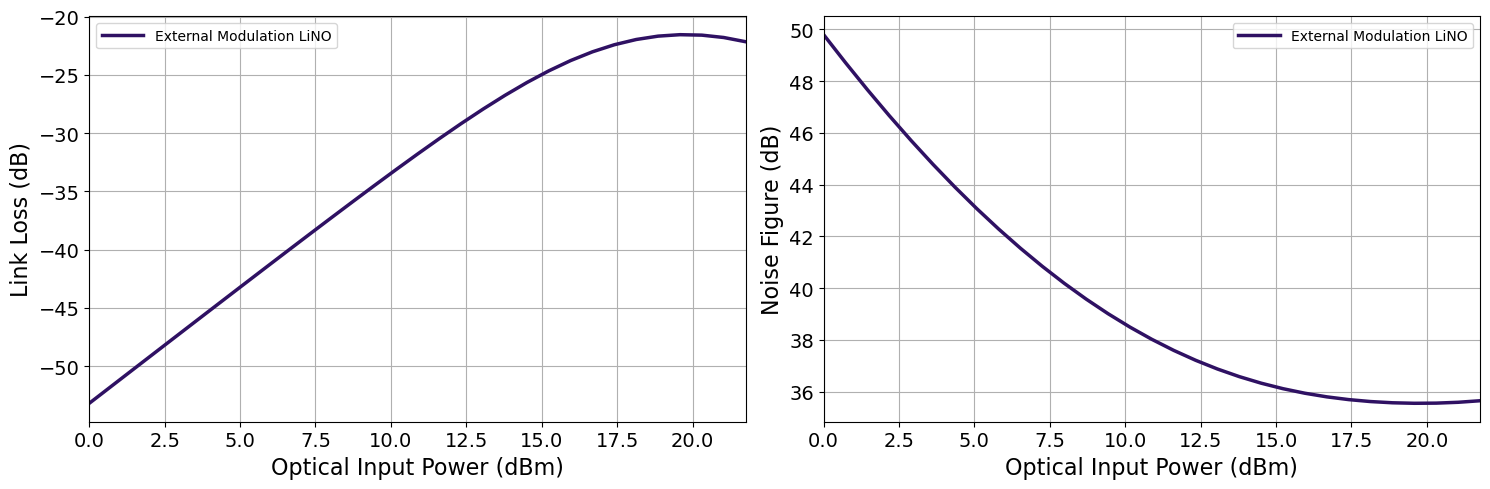

In [29]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(Pin,G_EM_LiNo, color =color_EM,linewidth=line_w,label=label_EM+' LiNO', linestyle = line_EM)
plt.ylabel('Link Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(30
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.subplot(1, 2, 2)
plt.plot(Pin,NF_EM_LiNo, color =color_EM,linewidth=line_w,label=label_EM+' LiNO', linestyle = line_EM)
plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(20,70)
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.tight_layout()
plt.show()

##### Although you are gaining from increasing optical power the nonlinear losses grow faster than the square increase in gain,
# P^2 and P^3, noise will stagnate becuase it is relative, and the power at the PD is actually not increasing significantly

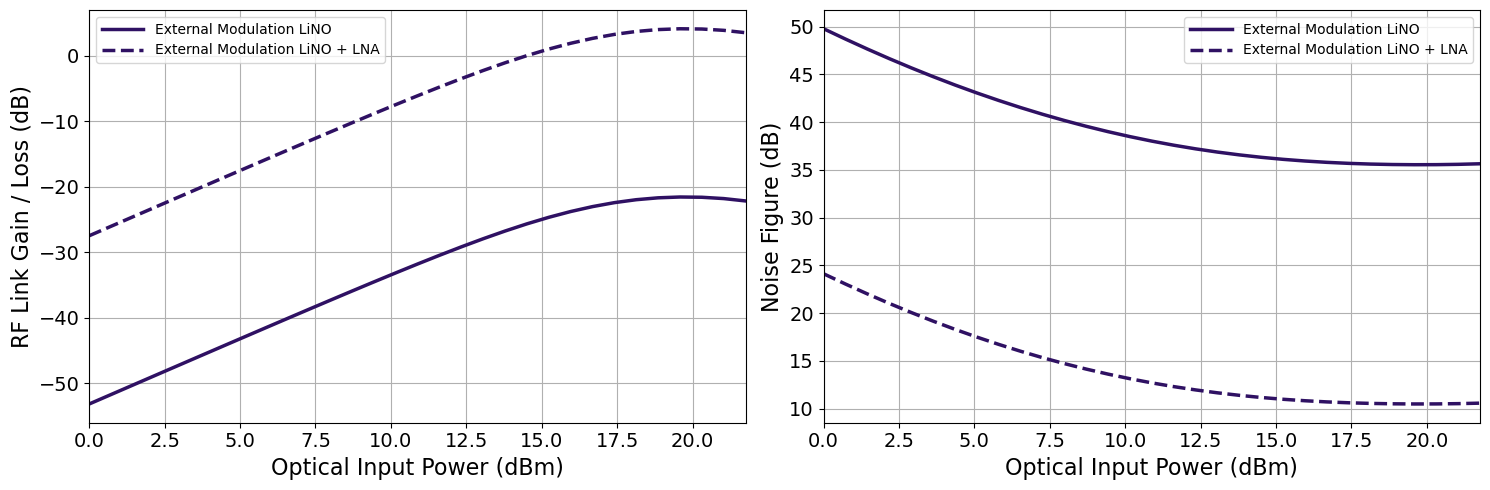

In [30]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

# Original LiNbO3 external modulation link
plt.plot(
    Pin,
    np.squeeze(G_EM_LiNo),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' LiNO',
    linestyle=line_EM
)

# LiNbO3 external modulation link with LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_LiNo_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' LiNO + LNA',
    linestyle='--'
)

plt.ylabel('RF Link Gain / Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')


plt.subplot(1, 2, 2)

# Original LiNbO3 external modulation noise figure
plt.plot(
    Pin,
    np.squeeze(NF_EM_LiNo),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' LiNO',
    linestyle=line_EM
)

# LiNbO3 external modulation noise figure with LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_LiNo_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' LiNO + LNA',
    linestyle='--'
)

plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')

plt.tight_layout()
plt.show()

### Thin Film Lithium Niobate

In [31]:
G_EM_TFLN = np.zeros((1,len(Pin)))
G_EM_lin_TFLN = np.zeros((1,len(Pin)))
NF_EM_TFLN = np.zeros((1,len(Pin)))
NF_EM_lin_TFLN = np.zeros((1,len(Pin)))
SFDR3_TFLN = np.zeros((1,len(Pin)))
SFDR3_lin_TFLN = np.zeros((1,len(Pin)))

# LNA-included quantities
G_EM_TFLN_LNA = np.zeros((1,len(Pin)))
G_EM_lin_TFLN_LNA = np.zeros((1,len(Pin)))
NF_EM_TFLN_LNA = np.zeros((1,len(Pin)))
NF_EM_lin_TFLN_LNA = np.zeros((1,len(Pin)))
SFDR3_TFLN_LNA = np.zeros((1,len(Pin)))

##############
# Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_TFLN,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_TFLN_mrr = db_to_lin(lin_to_db(Pin_lin_wg_TFLN) + Fanout_Loss)

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_TFLN_mrr * MRR_BU,
    model=model,
    ODEres=ODEres
)

# Total Optical Loss
Gopt = Gopt_nonlin_wg + Gopt_nonlin_mrr + IL_mrr + Fanout_Loss # dB
Gopt_lin = db_to_lin(Gopt)

# Link Gain / Loss
G_EM_lin_TFLN = (
    (1/4)
    * ((np.pi * Pin_lin * Tmod_TFLN_lin * RL) / (2 * Vpi_TFLN))**2
    * Gopt_lin**2
    * Rpd_Int**2
)
G_EM_TFLN = lin_to_db(G_EM_lin_TFLN)

# Noise Figure
NF_EM_lin_TFLN = (
    1
    + (16 * Vpi_TFLN**2)
      / (np.pi**2 * Pin_lin**2 * Gopt_lin**2 * Rpd_Int**2 * RL**2)
    + (16 * q * Vpi_TFLN**2)
      / (np.pi**2 * Pin_lin * Gopt_lin * Rpd_Int * RL * k * T)
    + (4 * Vpi_TFLN**2 * RIN_lin)
      / (np.pi**2 * RL * k * T)
)
NF_EM_TFLN = lin_to_db(NF_EM_lin_TFLN)

# ------------------------------------------------------------
# LNA cascade: LNA -> TFLN external-modulation photonic link
# ------------------------------------------------------------

# Friis cascaded NF
NF_EM_lin_TFLN_LNA = F_LNA_lin + (NF_EM_lin_TFLN - 1) / G_LNA_lin
NF_EM_TFLN_LNA = lin_to_db(NF_EM_lin_TFLN_LNA)

# Cascaded RF gain
G_EM_lin_TFLN_LNA = G_LNA_lin * G_EM_lin_TFLN
G_EM_TFLN_LNA = lin_to_db(G_EM_lin_TFLN_LNA)

# TFLN IIP3 estimate in watts
IIP3_TFLN_W = (4 * Vpi_TFLN**2) / (np.pi**2 * RL)

# Convert to dBm because SFDR equation uses +174 dBm/Hz
IIP3_TFLN_dBm = 10 * np.log10(IIP3_TFLN_W / 1e-3)

# Refer photonic-link IIP3 back to antenna/LNA input
IIP3_TFLN_referred_to_antenna = IIP3_TFLN_dBm - G_LNA_dB

# SFDR without LNA, referred to photonic-link RF input
SFDR_3_TFLN = (2/3) * (
    IIP3_TFLN_dBm
    - NF_EM_TFLN
    + 174
)

# SFDR with LNA, referred to antenna/LNA input
SFDR_3_TFLN_LNA = (2/3) * (
    IIP3_TFLN_referred_to_antenna
    - NF_EM_TFLN_LNA
    + 174
)

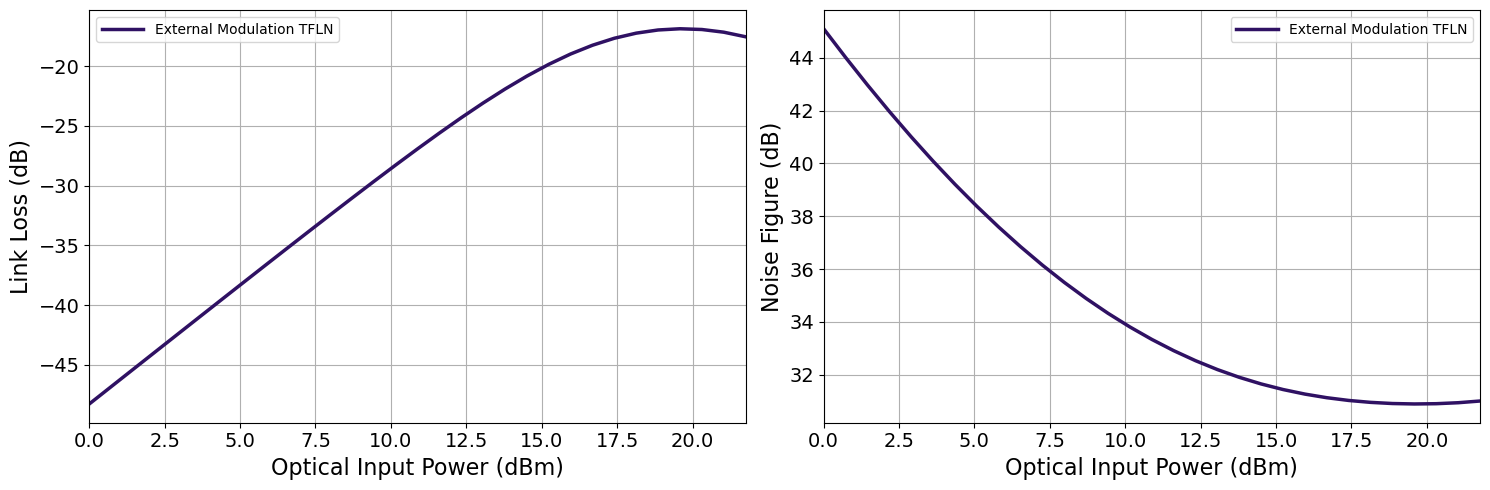

In [32]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(Pin,G_EM_TFLN, color =color_EM,linewidth=line_w,label=label_EM+' TFLN', linestyle = line_EM)
plt.ylabel('Link Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(30
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.subplot(1, 2, 2)
plt.plot(Pin,NF_EM_TFLN, color =color_EM,linewidth=line_w,label=label_EM+' TFLN', linestyle = line_EM)
plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(20,70)
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.tight_layout()
plt.show()

##### Although you are gaining from increasing optical power the nonlinear losses grow faster than the square increase in gain,
# P^2 and P^3, noise will stagnate becuase it is relative, and the power at the PD is actually not increasing significantly

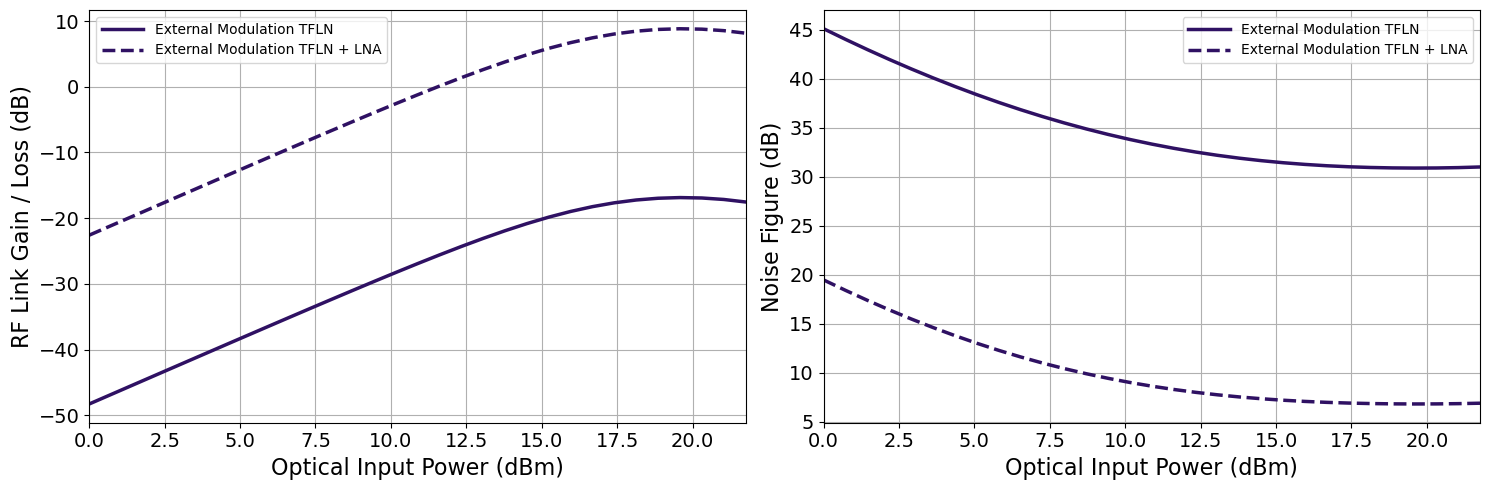

In [33]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

# TFLN external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_TFLN),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' TFLN',
    linestyle=line_EM
)

# TFLN external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_TFLN_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' TFLN + LNA',
    linestyle='--'
)

plt.ylabel('RF Link Gain / Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')


plt.subplot(1, 2, 2)

# TFLN external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_TFLN),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' TFLN',
    linestyle=line_EM
)

# TFLN external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_TFLN_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' TFLN + LNA',
    linestyle='--'
)

plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')

plt.tight_layout()
plt.show()

### Silicon Microring Modulator

In [34]:
G_EM_MRRMod = np.zeros((1,len(Pin)))
G_EM_lin_MRRMod = np.zeros((1,len(Pin)))
NF_EM_MRRMod = np.zeros((1,len(Pin)))
NF_EM_lin_MRRMod = np.zeros((1,len(Pin)))
SFDR3_MRRMod = np.zeros((1,len(Pin)))
SFDR3_lin_MRRMod = np.zeros((1,len(Pin)))

# LNA-included quantities
G_EM_MRRMod_LNA = np.zeros((1,len(Pin)))
G_EM_lin_MRRMod_LNA = np.zeros((1,len(Pin)))
NF_EM_MRRMod_LNA = np.zeros((1,len(Pin)))
NF_EM_lin_MRRMod_LNA = np.zeros((1,len(Pin)))
SFDR3_MRRMod_LNA = np.zeros((1,len(Pin)))

##############
# Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_MRRMod,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_MRRMod_mrr = db_to_lin(lin_to_db(Pin_lin_wg_MRRMod) + Fanout_Loss)

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_MRRMod_mrr * MRR_BU,
    model=model,
    ODEres=ODEres
)

# Total Optical Loss
Gopt = Gopt_nonlin_wg + Gopt_nonlin_mrr + IL_mrr + Fanout_Loss # dB
Gopt_lin = db_to_lin(Gopt)

# Link Gain / Loss
G_EM_lin_MRRMod = (
    (1/4)
    * ((np.pi * Pin_lin * Tmod_MRRMod_lin * RL) / (2 * Vpi_MRRMod))**2
    * Gopt_lin**2
    * Rpd_Int**2
)
G_EM_MRRMod = lin_to_db(G_EM_lin_MRRMod)

# Noise Figure
NF_EM_lin_MRRMod = (
    1
    + (16 * Vpi_MRRMod**2)
      / (np.pi**2 * Pin_lin**2 * Gopt_lin**2 * Rpd_Int**2 * RL**2)
    + (16 * q * Vpi_MRRMod**2)
      / (np.pi**2 * Pin_lin * Gopt_lin * Rpd_Int * RL * k * T)
    + (4 * Vpi_MRRMod**2 * RIN_lin)
      / (np.pi**2 * RL * k * T)
)
NF_EM_MRRMod = lin_to_db(NF_EM_lin_MRRMod)

# ------------------------------------------------------------
# LNA cascade: LNA -> MRR external-modulation photonic link
# ------------------------------------------------------------

# Friis cascaded NF
NF_EM_lin_MRRMod_LNA = F_LNA_lin + (NF_EM_lin_MRRMod - 1) / G_LNA_lin
NF_EM_MRRMod_LNA = lin_to_db(NF_EM_lin_MRRMod_LNA)

# Cascaded RF gain
G_EM_lin_MRRMod_LNA = G_LNA_lin * G_EM_lin_MRRMod
G_EM_MRRMod_LNA = lin_to_db(G_EM_lin_MRRMod_LNA)

# MRR modulator IIP3 estimate in watts
IIP3_MRRMod_W = (4 * Vpi_MRRMod**2) / (np.pi**2 * RL)

# Convert to dBm because SFDR equation uses +174 dBm/Hz
IIP3_MRRMod_dBm = 10 * np.log10(IIP3_MRRMod_W / 1e-3)

# Refer photonic-link IIP3 back to antenna/LNA input
IIP3_MRRMod_referred_to_antenna = IIP3_MRRMod_dBm - G_LNA_dB

# SFDR without LNA, referred to photonic-link RF input
SFDR_3_MRRMod = (2/3) * (
    IIP3_MRRMod_dBm
    - NF_EM_MRRMod
    + 174
)

# SFDR with LNA, referred to antenna/LNA input
SFDR_3_MRRMod_LNA = (2/3) * (
    IIP3_MRRMod_referred_to_antenna
    - NF_EM_MRRMod_LNA
    + 174
)

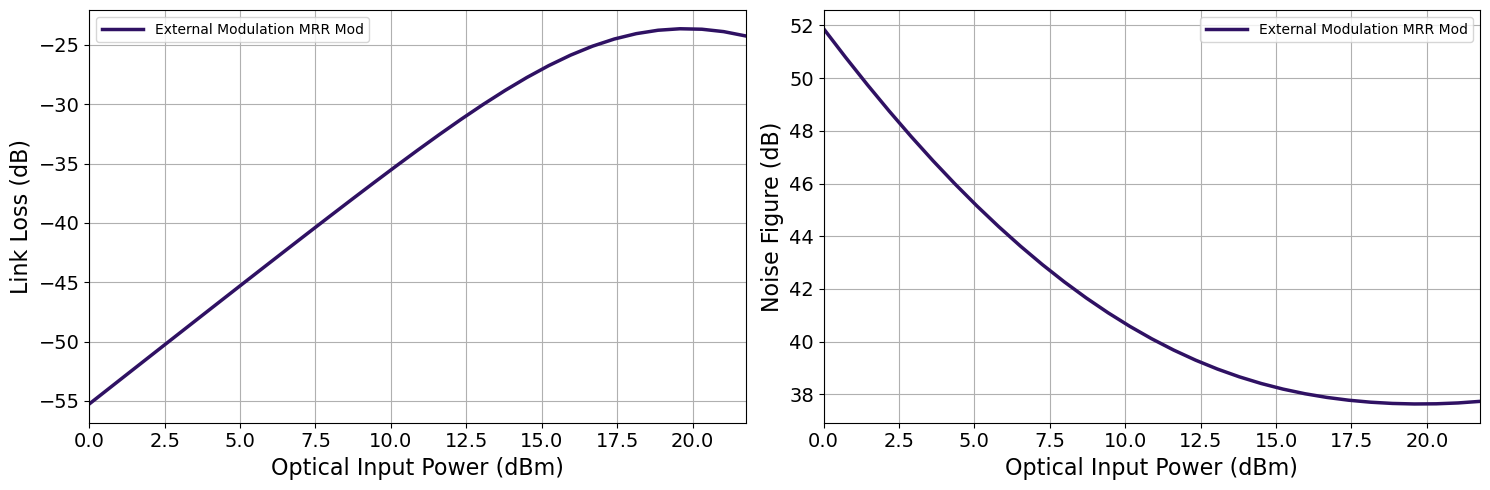

In [35]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(Pin,G_EM_MRRMod, color =color_EM,linewidth=line_w,label=label_EM+' MRR Mod', linestyle = line_EM)
plt.ylabel('Link Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(30
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.subplot(1, 2, 2)
plt.plot(Pin,NF_EM_MRRMod, color =color_EM,linewidth=line_w,label=label_EM+' MRR Mod', linestyle = line_EM)
plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(20,70)
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.tight_layout()
plt.show()

##### Although you are gaining from increasing optical power the nonlinear losses grow faster than the square increase in gain,
# P^2 and P^3, noise will stagnate becuase it is relative, and the power at the PD is actually not increasing significantly

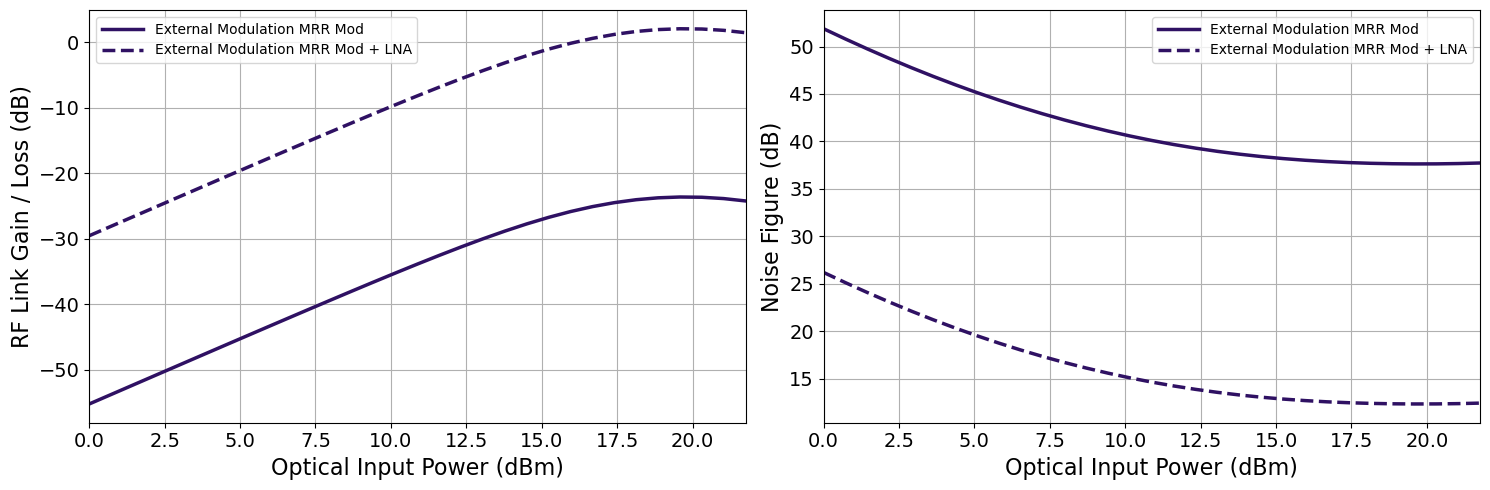

In [36]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

# MRR modulator external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_MRRMod),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MRR Mod',
    linestyle=line_EM
)

# MRR modulator external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_MRRMod_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MRR Mod + LNA',
    linestyle='--'
)

plt.ylabel('RF Link Gain / Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')


plt.subplot(1, 2, 2)

# MRR modulator external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_MRRMod),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MRR Mod',
    linestyle=line_EM
)

# MRR modulator external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_MRRMod_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MRR Mod + LNA',
    linestyle='--'
)

plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')

plt.tight_layout()
plt.show()

### Silicon Mach-Zehnder Modulator

In [37]:
G_EM_MZMMod = np.zeros((1,len(Pin)))
G_EM_lin_MZMMod = np.zeros((1,len(Pin)))
NF_EM_MZMMod = np.zeros((1,len(Pin)))
NF_EM_lin_MZMMod = np.zeros((1,len(Pin)))
SFDR3_MZMMod = np.zeros((1,len(Pin)))
SFDR3_lin_MZMMod = np.zeros((1,len(Pin)))

# LNA-included quantities
G_EM_MZMMod_LNA = np.zeros((1,len(Pin)))
G_EM_lin_MZMMod_LNA = np.zeros((1,len(Pin)))
NF_EM_MZMMod_LNA = np.zeros((1,len(Pin)))
NF_EM_lin_MZMMod_LNA = np.zeros((1,len(Pin)))
SFDR3_MZMMod_LNA = np.zeros((1,len(Pin)))

##############
# Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_MZMMod,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_MZMMod_mrr = db_to_lin(lin_to_db(Pin_lin_wg_MZMMod) + Fanout_Loss)

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_MZMMod_mrr * MRR_BU,
    model=model,
    ODEres=ODEres
)

# Total Optical Loss
Gopt = Gopt_nonlin_wg + Gopt_nonlin_mrr + IL_mrr + Fanout_Loss # dB
Gopt_lin = db_to_lin(Gopt)

# Link Gain / Loss
G_EM_lin_MZMMod = (
    (1/4)
    * ((np.pi * Pin_lin * Tmod_MZMMod_lin * RL) / (2 * Vpi_MZMMod))**2
    * Gopt_lin**2
    * Rpd_Int**2
)
G_EM_MZMMod = lin_to_db(G_EM_lin_MZMMod)

# Noise Figure
NF_EM_lin_MZMMod = (
    1
    + (16 * Vpi_MZMMod**2)
      / (np.pi**2 * Pin_lin**2 * Gopt_lin**2 * Rpd_Int**2 * RL**2)
    + (16 * q * Vpi_MZMMod**2)
      / (np.pi**2 * Pin_lin * Gopt_lin * Rpd_Int * RL * k * T)
    + (4 * Vpi_MZMMod**2 * RIN_lin)
      / (np.pi**2 * RL * k * T)
)
NF_EM_MZMMod = lin_to_db(NF_EM_lin_MZMMod)

# ------------------------------------------------------------
# LNA cascade: LNA -> MZM external-modulation photonic link
# ------------------------------------------------------------

# Friis cascaded NF
NF_EM_lin_MZMMod_LNA = F_LNA_lin + (NF_EM_lin_MZMMod - 1) / G_LNA_lin
NF_EM_MZMMod_LNA = lin_to_db(NF_EM_lin_MZMMod_LNA)

# Cascaded RF gain
G_EM_lin_MZMMod_LNA = G_LNA_lin * G_EM_lin_MZMMod
G_EM_MZMMod_LNA = lin_to_db(G_EM_lin_MZMMod_LNA)

# MZM modulator IIP3 estimate in watts
IIP3_MZMMod_W = (4 * Vpi_MZMMod**2) / (np.pi**2 * RL)

# Convert to dBm because SFDR equation uses +174 dBm/Hz
IIP3_MZMMod_dBm = 10 * np.log10(IIP3_MZMMod_W / 1e-3)

# Refer photonic-link IIP3 back to antenna/LNA input
IIP3_MZMMod_referred_to_antenna = IIP3_MZMMod_dBm - G_LNA_dB

# SFDR without LNA, referred to photonic-link RF input
SFDR_3_MZMMod = (2/3) * (
    IIP3_MZMMod_dBm
    - NF_EM_MZMMod
    + 174
)

# SFDR with LNA, referred to antenna/LNA input
SFDR_3_MZMMod_LNA = (2/3) * (
    IIP3_MZMMod_referred_to_antenna
    - NF_EM_MZMMod_LNA
    + 174
)

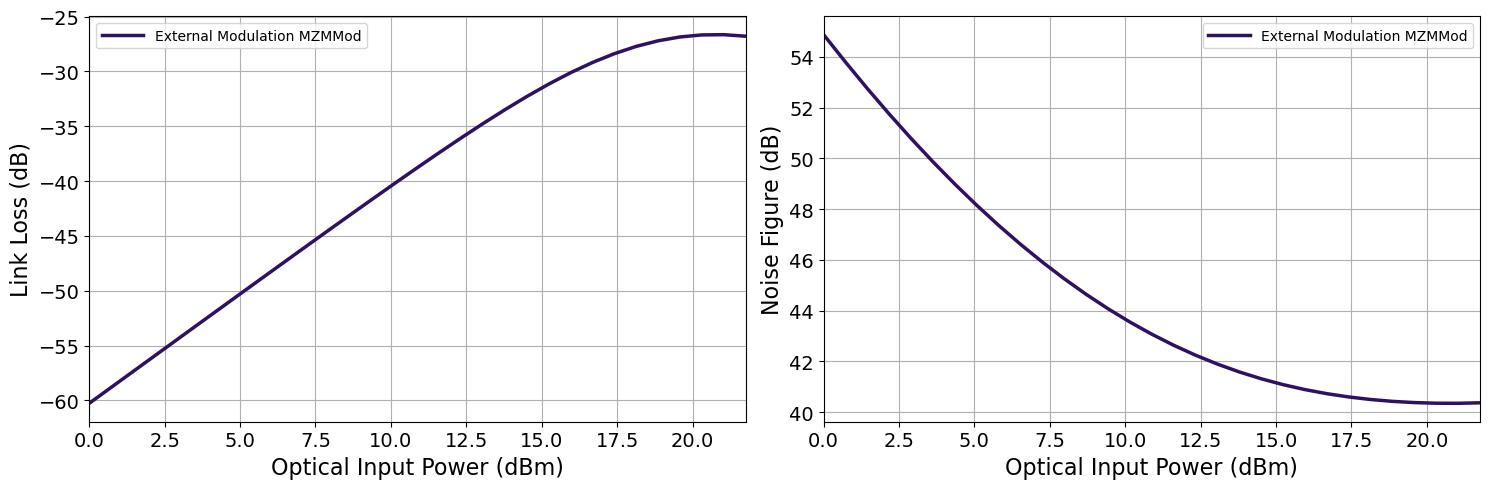

In [38]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(Pin,G_EM_MZMMod, color =color_EM,linewidth=line_w,label=label_EM+' MZMMod', linestyle = line_EM)
plt.ylabel('Link Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(30
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.subplot(1, 2, 2)
plt.plot(Pin,NF_EM_MZMMod, color =color_EM,linewidth=line_w,label=label_EM+' MZMMod', linestyle = line_EM)
plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(20,70)
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.tight_layout()
plt.show()

##### Although you are gaining from increasing optical power the nonlinear losses grow faster than the square increase in gain,
# P^2 and P^3, noise will stagnate becuase it is relative, and the power at the PD is actually not increasing significantly

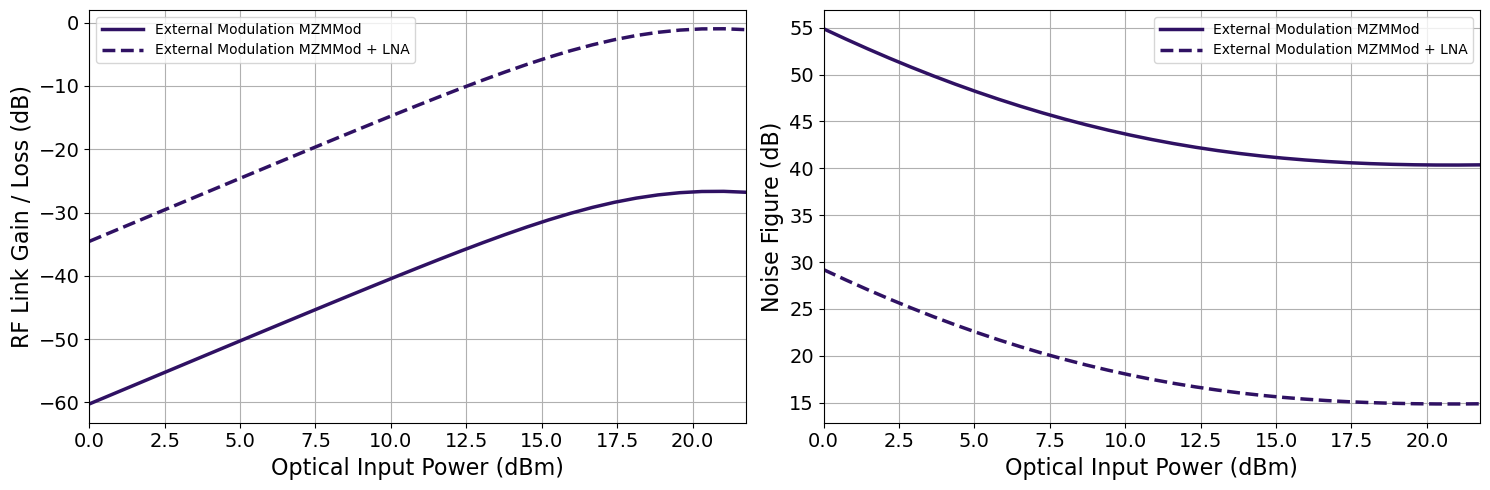

In [39]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

# MZM modulator external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_MZMMod),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MZMMod',
    linestyle=line_EM
)

# MZM modulator external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_MZMMod_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MZMMod + LNA',
    linestyle='--'
)

plt.ylabel('RF Link Gain / Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')


plt.subplot(1, 2, 2)

# MZM modulator external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_MZMMod),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MZMMod',
    linestyle=line_EM
)

# MZM modulator external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_MZMMod_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' MZMMod + LNA',
    linestyle='--'
)

plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')

plt.tight_layout()
plt.show()

### Barium titanate ( B a T i O 3 , BTO) Modulator

In [40]:
G_EM_BTO = np.zeros((1,len(Pin)))
G_EM_lin_BTO = np.zeros((1,len(Pin)))
NF_EM_BTO = np.zeros((1,len(Pin)))
NF_EM_lin_BTO = np.zeros((1,len(Pin)))
SFDR3_BTO = np.zeros((1,len(Pin)))
SFDR3_lin_BTO = np.zeros((1,len(Pin)))

# LNA-included quantities
G_EM_BTO_LNA = np.zeros((1,len(Pin)))
G_EM_lin_BTO_LNA = np.zeros((1,len(Pin)))
NF_EM_BTO_LNA = np.zeros((1,len(Pin)))
NF_EM_lin_BTO_LNA = np.zeros((1,len(Pin)))
SFDR3_BTO_LNA = np.zeros((1,len(Pin)))

##############
# Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_BTO,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_BTO_mrr = db_to_lin(lin_to_db(Pin_lin_wg_BTO) + Fanout_Loss)

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_BTO_mrr * MRR_BU,
    model=model,
    ODEres=ODEres
)

# Total Optical Loss
Gopt = Gopt_nonlin_wg + Gopt_nonlin_mrr + IL_mrr + Fanout_Loss # dB
Gopt_lin = db_to_lin(Gopt)

# Link Gain / Loss
G_EM_lin_BTO = (
    (1/4)
    * ((np.pi * Pin_lin * Tmod_BTO_lin * RL) / (2 * Vpi_BTO))**2
    * Gopt_lin**2
    * Rpd_Int**2
)
G_EM_BTO = lin_to_db(G_EM_lin_BTO)

# Noise Figure
NF_EM_lin_BTO = (
    1
    + (16 * Vpi_BTO**2)
      / (np.pi**2 * Pin_lin**2 * Gopt_lin**2 * Rpd_Int**2 * RL**2)
    + (16 * q * Vpi_BTO**2)
      / (np.pi**2 * Pin_lin * Gopt_lin * Rpd_Int * RL * k * T)
    + (4 * Vpi_BTO**2 * RIN_lin)
      / (np.pi**2 * RL * k * T)
)
NF_EM_BTO = lin_to_db(NF_EM_lin_BTO)

# ------------------------------------------------------------
# LNA cascade: LNA -> BTO external-modulation photonic link
# ------------------------------------------------------------

# Friis cascaded NF
NF_EM_lin_BTO_LNA = F_LNA_lin + (NF_EM_lin_BTO - 1) / G_LNA_lin
NF_EM_BTO_LNA = lin_to_db(NF_EM_lin_BTO_LNA)

# Cascaded RF gain
G_EM_lin_BTO_LNA = G_LNA_lin * G_EM_lin_BTO
G_EM_BTO_LNA = lin_to_db(G_EM_lin_BTO_LNA)

# BTO modulator IIP3 estimate in watts
IIP3_BTO_W = (4 * Vpi_BTO**2) / (np.pi**2 * RL)

# Convert to dBm because SFDR equation uses +174 dBm/Hz
IIP3_BTO_dBm = 10 * np.log10(IIP3_BTO_W / 1e-3)

# Refer photonic-link IIP3 back to antenna/LNA input
IIP3_BTO_referred_to_antenna = IIP3_BTO_dBm - G_LNA_dB

# SFDR without LNA, referred to photonic-link RF input
SFDR_3_BTO = (2/3) * (
    IIP3_BTO_dBm
    - NF_EM_BTO
    + 174
)

# SFDR with LNA, referred to antenna/LNA input
SFDR_3_BTO_LNA = (2/3) * (
    IIP3_BTO_referred_to_antenna
    - NF_EM_BTO_LNA
    + 174
)

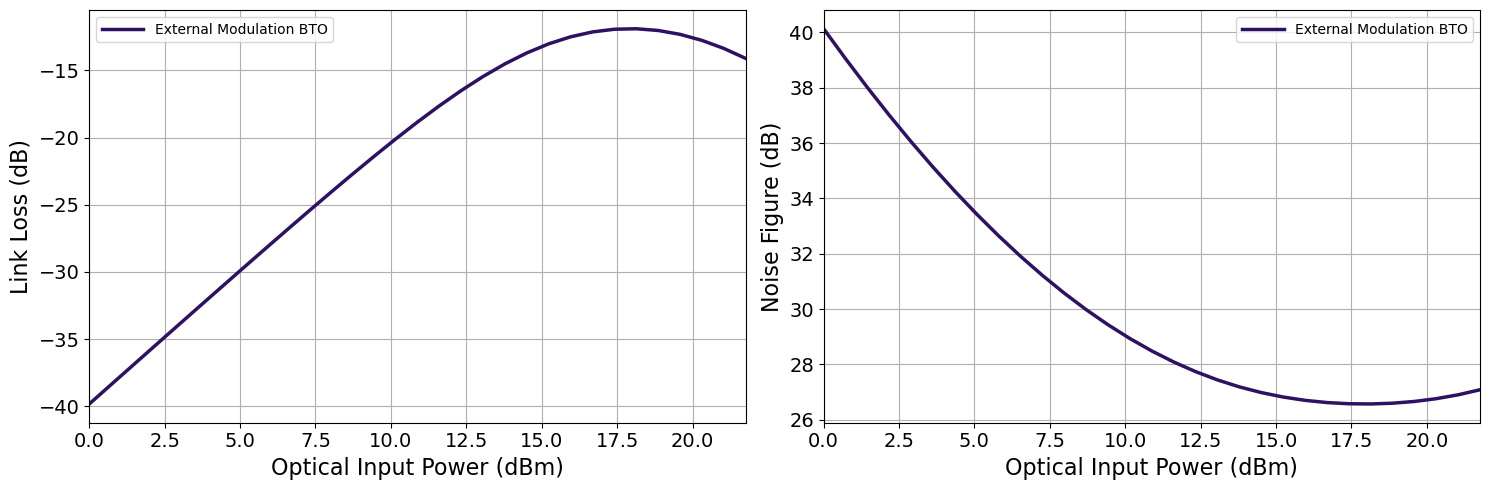

In [41]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(Pin,G_EM_BTO, color =color_EM,linewidth=line_w,label=label_EM+' BTO', linestyle = line_EM)
plt.ylabel('Link Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(30
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.subplot(1, 2, 2)
plt.plot(Pin,NF_EM_BTO, color =color_EM,linewidth=line_w,label=label_EM+' BTO', linestyle = line_EM)
plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

plt.xlim(0,Pin_max)
# plt.ylim(20,70)
# plt.gca().invert_yaxis()
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')
plt.tight_layout()
plt.show()

##### Although you are gaining from increasing optical power the nonlinear losses grow faster than the square increase in gain,
# P^2 and P^3, noise will stagnate becuase it is relative, and the power at the PD is actually not increasing significantly

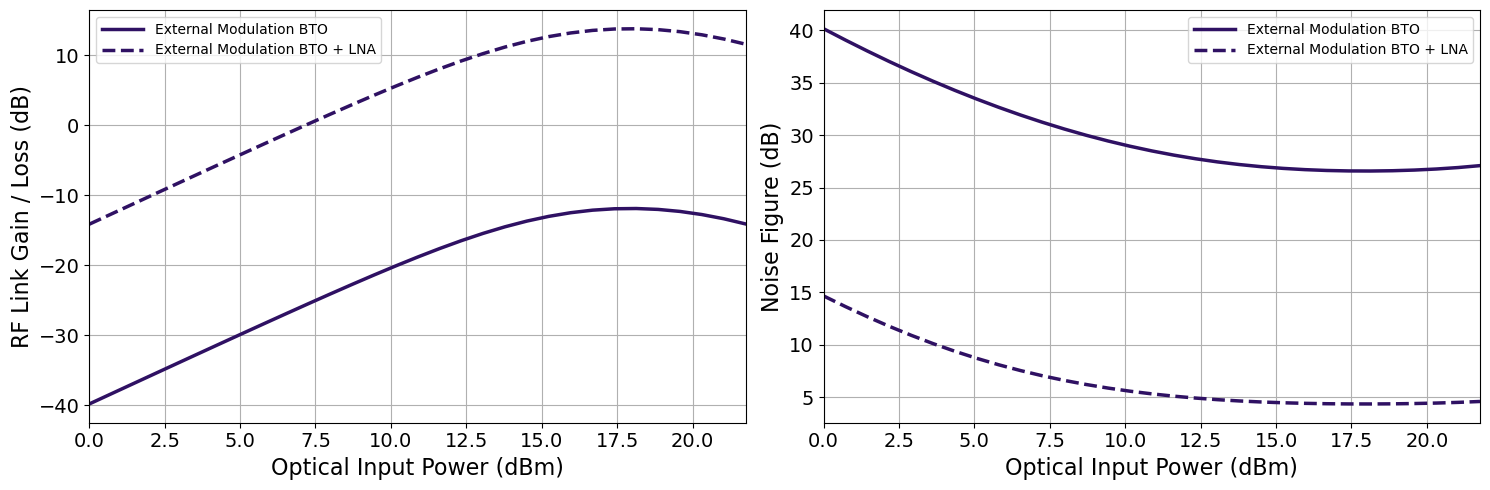

In [42]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)

# BTO external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_BTO),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' BTO',
    linestyle=line_EM
)

# BTO external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(G_EM_BTO_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' BTO + LNA',
    linestyle='--'
)

plt.ylabel('RF Link Gain / Loss (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')


plt.subplot(1, 2, 2)

# BTO external modulation, no LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_BTO),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' BTO',
    linestyle=line_EM
)

# BTO external modulation, with LNA
plt.plot(
    Pin,
    np.squeeze(NF_EM_BTO_LNA),
    color=color_EM,
    linewidth=line_w,
    label=label_EM + ' BTO + LNA',
    linestyle='--'
)

plt.ylabel('Noise Figure (dB)', fontsize=fs)
plt.xlabel('Optical Input Power (dBm)', fontsize=fs)

plt.xlim(0, Pin_max)
plt.xticks(fontsize=fs-2)
plt.yticks(fontsize=fs-2)
plt.grid(which='major', axis='both')
plt.legend(handlelength=3, loc='best')

plt.tight_layout()
plt.show()

### Combined Plotting

In [43]:
# fig = plt.figure(figsize=(15, 5))

# plt.subplot(1, 2, 1)
# plt.plot(Pin,G_EM_LiNo, color   =color[0],linewidth=line_w,label=label_EM+' LiNo', linestyle = line_EM)
# plt.plot(Pin,G_EM_TFLN, color   =color[1],linewidth=line_w,label=label_EM+' TFNL', linestyle = line_EM)
# plt.plot(Pin,G_EM_MRRMod, color =color[2],linewidth=line_w,label=label_EM+' MRR', linestyle = line_EM)
# plt.plot(Pin,G_EM_MZMMod, color =color[3],linewidth=line_w,label=label_EM+' MZM', linestyle = line_EM)
# plt.plot(Pin,G_EM_BTO, color =color[4],linewidth=line_w,label=label_EM+' BTO', linestyle = line_EM)
# plt.plot(Pin_DML, np.squeeze(G_DM), color=color_DM, linewidth=line_w, label=label_DM, linestyle=line_DM)
# plt.ylabel('Link Loss (dB)', fontsize=fs)
# plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# # plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

# plt.xlim(0,Pin_max)
# # plt.ylim(30
# # plt.gca().invert_yaxis()
# plt.xticks(fontsize=fs-2)
# plt.yticks(fontsize=fs-2)
# plt.grid(which='major', axis='both')
# plt.legend(handlelength=3, loc='best')
# plt.subplot(1, 2, 2)
# plt.plot(Pin,NF_EM_LiNo, color   =color[0],linewidth=line_w,label=label_EM+' LiNo', linestyle = line_EM)
# plt.plot(Pin,NF_EM_TFLN, color   =color[1],linewidth=line_w,label=label_EM+' TFNL', linestyle = line_EM)
# plt.plot(Pin,NF_EM_MRRMod, color =color[2],linewidth=line_w,label=label_EM+' MRR', linestyle = line_EM)
# plt.plot(Pin,NF_EM_MZMMod, color =color[3],linewidth=line_w,label=label_EM+' MZM', linestyle = line_EM)
# plt.plot(Pin,NF_EM_BTO, color =color[4],linewidth=line_w,label=label_EM+' BTO', linestyle = line_EM)
# plt.plot(Pin_DML, np.squeeze(NF_DM), color=color_DM, linewidth=line_w, label=label_DM, linestyle=line_DM)
# plt.ylabel('Noise Figure (dB)', fontsize=fs)
# plt.xlabel('Optical Input Power (dBm)', fontsize=fs)
# # plt.title('RF Link Loss of Rx path for Canceller Architectures ', fontsize=15)

# plt.xlim(0,Pin_max)
# # plt.ylim(20,70)
# # plt.gca().invert_yaxis()
# plt.xticks(fontsize=fs-2)
# plt.yticks(fontsize=fs-2)
# plt.grid(which='major', axis='both')
# # plt.legend(handlelength=3, loc='best')
# plt.tight_layout()
# plt.show()


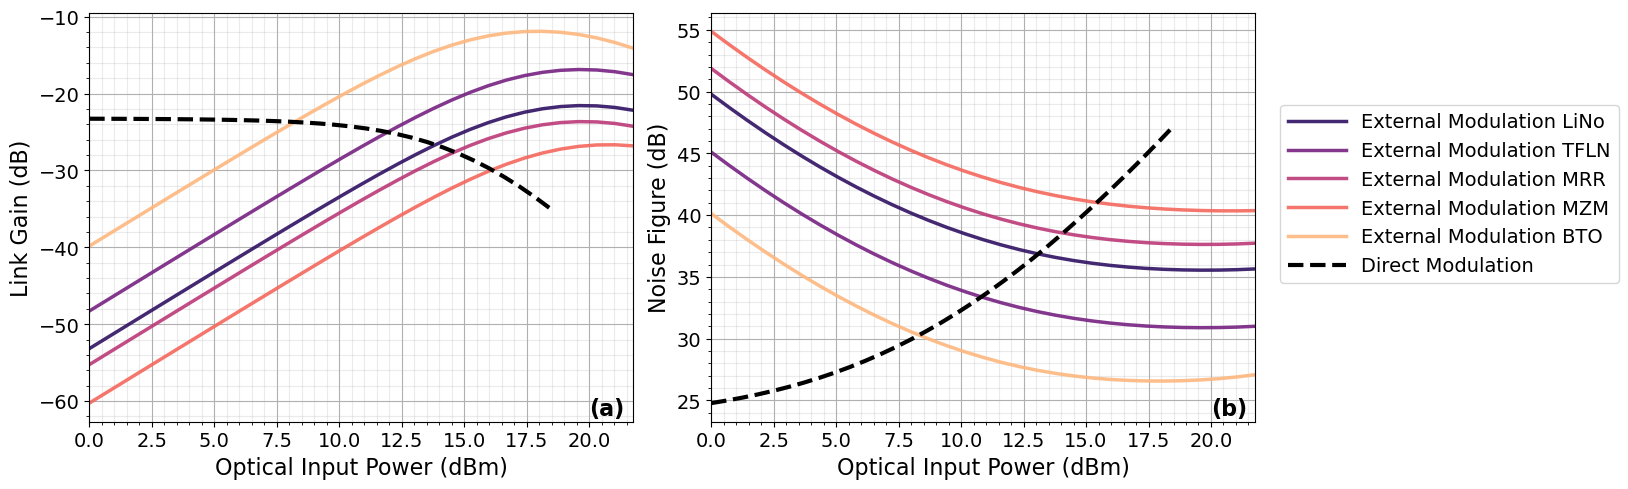

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# --- Styling ---
alpha_em = 0.9
lw_em = line_w
lw_dm = line_w + 0.5  # emphasize DML slightly

# If you want DML to stand out regardless of palette:
dm_color = 'k'   # black
dm_ls = '--'     # dashed

# -------------------------
# Left: Link Loss / Gain
# -------------------------
ax = axs[0]
ax.plot(Pin, G_EM_LiNo,    color=color[0], linewidth=lw_em, alpha=alpha_em, label=label_EM+' LiNo', linestyle=line_EM)
ax.plot(Pin, G_EM_TFLN,    color=color[1], linewidth=lw_em, alpha=alpha_em, label=label_EM+' TFLN', linestyle=line_EM)
ax.plot(Pin, G_EM_MRRMod,  color=color[2], linewidth=lw_em, alpha=alpha_em, label=label_EM+' MRR',  linestyle=line_EM)
ax.plot(Pin, G_EM_MZMMod,  color=color[3], linewidth=lw_em, alpha=alpha_em, label=label_EM+' MZM',  linestyle=line_EM)
ax.plot(Pin, G_EM_BTO,     color=color[4], linewidth=lw_em, alpha=alpha_em, label=label_EM+' BTO',  linestyle=line_EM)
ax.plot(Pin_DML, np.squeeze(G_DM), color=dm_color, linewidth=lw_dm, label=label_DM, linestyle=dm_ls)

ax.set_ylabel('Link Gain (dB)', fontsize=fs)
ax.set_xlabel('Optical Input Power (dBm)', fontsize=fs)
ax.set_xlim(0, Pin_max)
ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.25)

ax.tick_params(axis='both', labelsize=fs-2)
axs[0].text(0.92, 0.06,'(a)', transform=axs[0].transAxes,
            fontsize=fs, fontweight='bold', va='top')
# axs[0].text(
#     -0.12, 1.05, '(a)',
#     transform=axs[0].transAxes,
#     fontsize=fs,
#     fontweight='bold',
#     va='top'
# )

# -------------------------
# Right: Noise Figure
# -------------------------
ax = axs[1]
ax.plot(Pin, NF_EM_LiNo,   color=color[0], linewidth=lw_em, alpha=alpha_em, label=label_EM+' LiNo', linestyle=line_EM)
ax.plot(Pin, NF_EM_TFLN,   color=color[1], linewidth=lw_em, alpha=alpha_em, label=label_EM+' TFLN', linestyle=line_EM)
ax.plot(Pin, NF_EM_MRRMod, color=color[2], linewidth=lw_em, alpha=alpha_em, label=label_EM+' MRR',  linestyle=line_EM)
ax.plot(Pin, NF_EM_MZMMod, color=color[3], linewidth=lw_em, alpha=alpha_em, label=label_EM+' MZM',  linestyle=line_EM)
ax.plot(Pin, NF_EM_BTO,    color=color[4], linewidth=lw_em, alpha=alpha_em, label=label_EM+' BTO',  linestyle=line_EM)
ax.plot(Pin_DML, np.squeeze(NF_DM), color=dm_color, linewidth=lw_dm, label=label_DM, linestyle=dm_ls)

ax.set_ylabel('Noise Figure (dB)', fontsize=fs)
ax.set_xlabel('Optical Input Power (dBm)', fontsize=fs)
ax.set_xlim(0, Pin_max)
ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.25)

ax.tick_params(axis='both', labelsize=fs-2)
axs[1].text(0.92, 0.06, '(b)', transform=axs[1].transAxes,
            fontsize=fs, fontweight='bold', va='top')
# axs[1].text(
#     -0.12, 1.05, '(b)',
#     transform=axs[1].transAxes,
#     fontsize=fs,
#     fontweight='bold',
#     va='top'
# )

# -------------------------
# One shared legend (outside)
# -------------------------
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(.85, 0.6),
           frameon=True, fontsize=fs-2, handlelength=3)

fig.tight_layout(rect=[0, 0, 0.85, 1])  # leave room for legend

if isSaving:
    outputFile = 'RF_Analysis_Linear'
    plt.savefig(outputFile + '.pdf', format='pdf', dpi=dpi_res, bbox_inches='tight')
    plt.savefig(outputFile + '.png', format='pdf', dpi=dpi_res, bbox_inches='tight')

plt.show()

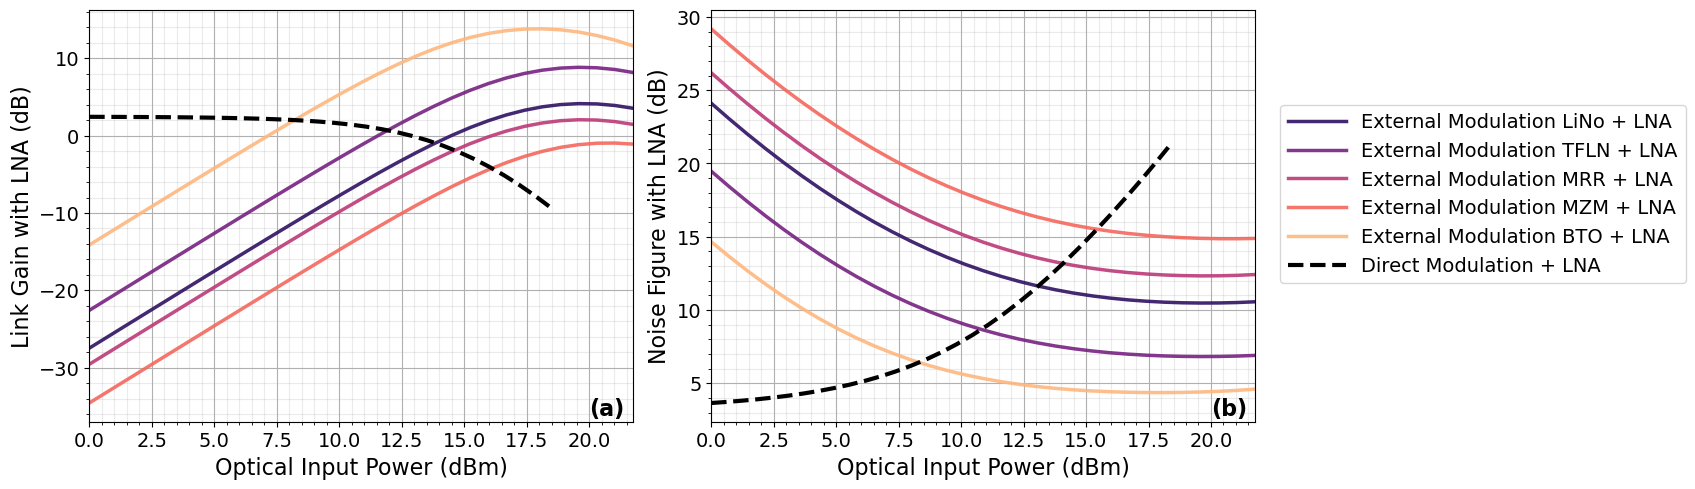

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# --- Styling ---
alpha_em = 0.9
lw_em = line_w
lw_dm = line_w + 0.5  # emphasize DML slightly

# If you want DML to stand out regardless of palette:
dm_color = 'k'   # black
dm_ls = '--'     # dashed

# -------------------------
# Left: Link Loss / Gain with LNA
# -------------------------
ax = axs[0]
ax.plot(Pin, G_EM_LiNo_LNA,    color=color[0], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' LiNo + LNA', linestyle=line_EM)
ax.plot(Pin, G_EM_TFLN_LNA,    color=color[1], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' TFLN + LNA', linestyle=line_EM)
ax.plot(Pin, G_EM_MRRMod_LNA,  color=color[2], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' MRR + LNA',  linestyle=line_EM)
ax.plot(Pin, G_EM_MZMMod_LNA,  color=color[3], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' MZM + LNA',  linestyle=line_EM)
ax.plot(Pin, G_EM_BTO_LNA,     color=color[4], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' BTO + LNA',  linestyle=line_EM)
ax.plot(Pin_DML, np.squeeze(G_DM_LNA), color=dm_color, linewidth=lw_dm, label=label_DM + ' + LNA', linestyle=dm_ls)

ax.set_ylabel('Link Gain with LNA (dB)', fontsize=fs)
ax.set_xlabel('Optical Input Power (dBm)', fontsize=fs)
ax.set_xlim(0, Pin_max)
ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.25)

ax.tick_params(axis='both', labelsize=fs-2)
axs[0].text(
    0.92, 0.06, '(a)',
    transform=axs[0].transAxes,
    fontsize=fs,
    fontweight='bold',
    va='top'
)

# -------------------------
# Right: Noise Figure with LNA
# -------------------------
ax = axs[1]
ax.plot(Pin, NF_EM_LiNo_LNA,   color=color[0], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' LiNo + LNA', linestyle=line_EM)
ax.plot(Pin, NF_EM_TFLN_LNA,   color=color[1], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' TFLN + LNA', linestyle=line_EM)
ax.plot(Pin, NF_EM_MRRMod_LNA, color=color[2], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' MRR + LNA',  linestyle=line_EM)
ax.plot(Pin, NF_EM_MZMMod_LNA, color=color[3], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' MZM + LNA',  linestyle=line_EM)
ax.plot(Pin, NF_EM_BTO_LNA,    color=color[4], linewidth=lw_em, alpha=alpha_em, label=label_EM + ' BTO + LNA',  linestyle=line_EM)
ax.plot(Pin_DML, np.squeeze(NF_DM_LNA), color=dm_color, linewidth=lw_dm, label=label_DM + ' + LNA', linestyle=dm_ls)

ax.set_ylabel('Noise Figure with LNA (dB)', fontsize=fs)
ax.set_xlabel('Optical Input Power (dBm)', fontsize=fs)
ax.set_xlim(0, Pin_max)
ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.25)

ax.tick_params(axis='both', labelsize=fs-2)
axs[1].text(
    0.92, 0.06, '(b)',
    transform=axs[1].transAxes,
    fontsize=fs,
    fontweight='bold',
    va='top'
)

# -------------------------
# One shared legend outside
# -------------------------
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(0.85, 0.6),
    frameon=True,
    fontsize=fs-2,
    handlelength=3
)

fig.tight_layout(rect=[0, 0, 0.85, 1])  # leave room for legend

if isSaving:
    outputFile = 'RF_Analysis_Linear_LNA'
    plt.savefig(outputFile + '.pdf', format='pdf', dpi=dpi_res, bbox_inches='tight')
    plt.savefig(outputFile + '.png', format='pdf', dpi=dpi_res, bbox_inches='tight')

plt.show()

In [46]:


rows = []

rows.append(best_metrics(
    "EM LiNo",
    Pin,
    G_EM_LiNo,
    NF_EM_LiNo,
    G_EM_LiNo_LNA,
    NF_EM_LiNo_LNA
))

rows.append(best_metrics(
    "EM TFLN",
    Pin,
    G_EM_TFLN,
    NF_EM_TFLN,
    G_EM_TFLN_LNA,
    NF_EM_TFLN_LNA
))

rows.append(best_metrics(
    "EM MRR Mod",
    Pin,
    G_EM_MRRMod,
    NF_EM_MRRMod,
    G_EM_MRRMod_LNA,
    NF_EM_MRRMod_LNA
))

rows.append(best_metrics(
    "EM MZM Mod",
    Pin,
    G_EM_MZMMod,
    NF_EM_MZMMod,
    G_EM_MZMMod_LNA,
    NF_EM_MZMMod_LNA
))

rows.append(best_metrics(
    "EM BTO",
    Pin,
    G_EM_BTO,
    NF_EM_BTO,
    G_EM_BTO_LNA,
    NF_EM_BTO_LNA
))

rows.append(best_metrics(
    "DML",
    Pin_DML,
    np.squeeze(G_DM),
    np.squeeze(NF_DM),
    np.squeeze(G_DM_LNA),
    np.squeeze(NF_DM_LNA)
))

summary_table = pd.DataFrame(rows)

# Optional rounding for clean display
summary_table_rounded = summary_table.round(2)

display(summary_table_rounded)

,Architecture,Best Gain No LNA (dB),Pin at Best Gain No LNA (dBm),Best NF No LNA (dB),Pin at Best NF No LNA (dBm),Best Gain With LNA (dB),Pin at Best Gain With LNA (dBm),Best NF With LNA (dB),Pin at Best NF With LNA (dBm)
0,EM LiNo,-21.56,19.58,35.55,19.58,4.14,19.58,10.48,19.58
1,EM TFLN,-16.87,19.58,30.89,19.58,8.83,19.58,6.83,19.58
2,EM MRR Mod,-23.64,19.58,37.63,19.58,2.06,19.58,12.33,19.58
3,EM MZM Mod,-26.66,21.04,40.35,21.04,-0.96,21.04,14.87,21.04
4,EM BTO,-11.89,18.13,26.57,18.13,13.81,18.13,4.37,18.13
5,DML,-23.26,0.00,24.78,0.00,2.44,0.00,3.66,0.00


In [47]:
summary_rows = []

summary_rows.append(summarize_gain_nf_no_pin(
    "EM LiNo",
    G_EM_LiNo,
    NF_EM_LiNo,
    G_EM_LiNo_LNA,
    NF_EM_LiNo_LNA
))

summary_rows.append(summarize_gain_nf_no_pin(
    "EM TFLN",
    G_EM_TFLN,
    NF_EM_TFLN,
    G_EM_TFLN_LNA,
    NF_EM_TFLN_LNA
))

summary_rows.append(summarize_gain_nf_no_pin(
    "EM MRR Mod",
    G_EM_MRRMod,
    NF_EM_MRRMod,
    G_EM_MRRMod_LNA,
    NF_EM_MRRMod_LNA
))

summary_rows.append(summarize_gain_nf_no_pin(
    "EM MZM Mod",
    G_EM_MZMMod,
    NF_EM_MZMMod,
    G_EM_MZMMod_LNA,
    NF_EM_MZMMod_LNA
))

summary_rows.append(summarize_gain_nf_no_pin(
    "EM BTO",
    G_EM_BTO,
    NF_EM_BTO,
    G_EM_BTO_LNA,
    NF_EM_BTO_LNA
))

summary_rows.append(summarize_gain_nf_no_pin(
    "DML",
    G_DM,
    NF_DM,
    G_DM_LNA,
    NF_DM_LNA
))

summary_gain_nf = pd.DataFrame(summary_rows)

summary_gain_nf = summary_gain_nf.round(2)

display(summary_gain_nf)

,Architecture,Best G No LNA (dB),Best NF No LNA (dB),Best G With LNA (dB),Best NF With LNA (dB)
0,EM LiNo,-21.56,35.55,4.14,10.48
1,EM TFLN,-16.87,30.89,8.83,6.83
2,EM MRR Mod,-23.64,37.63,2.06,12.33
3,EM MZM Mod,-26.66,40.35,-0.96,14.87
4,EM BTO,-11.89,26.57,13.81,4.37
5,DML,-23.26,24.78,2.44,3.66


### Nonlinear Scaling Consideration

In [48]:
### WDM Neural Neuron
### Laser -> Nonlinear MRR Modulation -> Fanout -> MRR Weight Bank -> BPD  
### Sources: DFB Laser
### Modulation: Nonlinear MRR Modulation

# ###### Nonlinear Vpi from Yusuf Data
# # Calculate from experimental data Voltage required for a LW shift


In [49]:
#Nonlinear Gain Term
# Reference: Josh Lederman (Need to back calculate out gain) 
# Lederman, Joshua C., et al. "Integrated optical-to-optical gain in a silicon photonic modulator neuron." Optica 12.12 (2025): 1904-1911
# Tait, Alexander N., et al. "Silicon photonic modulator neuron." Physical Review Applied 11.6 (2019): 064043.
# The optical-to-optical gain is measured by comparing
# the amplitude of the modulation swing on the λ1 input to
# the amplitude of the modulation swing on the λn output
# coming from the neuron. It is found to be 2.16 × 10−2,
G_Taitmod_lin = 2.15e-2
G_Taitmod = 10*np.log10(G_Taitmod_lin) # -16.67

# Josh Results
G_NL_v = 14.1 # Voltage dB gain
G_NL_v_lin = 10**(G_NL_v/20)   # 5.06; linear Voltage Gain
G_NL_lin = G_NL_v_lin**2 # 25.6
G_NL = 10*np.log10(G_NL_lin) # 14.1
# print(G_NL)

# # Could compare to typical MRR link
# Vpi_NLmod = 0.01171875 / NL_gain_factor #V
# Tmod_NLmod =  -3  #dB 



In [50]:
G_EM_MRRModNL = np.zeros((1,len(Pin)))
G_EM_lin_MRRModNL = np.zeros((1,len(Pin)))
NF_EM_MRRModNL = np.zeros((1,len(Pin)))
NF_EM_lin_MRRModNL = np.zeros((1,len(Pin)))
SFDR3_MRRModNL = np.zeros((1,len(Pin)))
SFDR3_lin_MRRModNL = np.zeros((1,len(Pin)))
G_EM_MRRModL = np.zeros((1,len(Pin)))
G_EM_lin_MRRModL = np.zeros((1,len(Pin)))
NF_EM_MRRModL = np.zeros((1,len(Pin)))
NF_EM_lin_MRRModL = np.zeros((1,len(Pin)))
SFDR3_MRRModL = np.zeros((1,len(Pin)))
SFDR3_lin_MRRModL = np.zeros((1,len(Pin)))

wg_length = .02
##############
#Nonlinear WG loss
Gopt_nonlin_wg = compute_nonlinear_gain(
    wg_length = wg_length,
    Pin_lin_wg = Pin_lin_wg_MRRModNL,
    model=model,
    ODEres=ODEres
)

# Waveguide and then MRR
Pin_lin_wg_MRRModNL_mrr = db_to_lin(lin_to_db(Pin_lin_wg_MRRModNL))

####### Nonlinear MRR Loss
Gopt_nonlin_mrr = compute_nonlinear_gain(
    wg_length = c_bssmrr,
    Pin_lin_wg = Pin_lin_wg_MRRModNL_mrr*MRR_BU,
    model=model,
    ODEres=ODEres
)

# Total Optical Loss
Gopt = Gopt_nonlin_wg+Gopt_nonlin_mrr #dB
Gopt_lin = db_to_lin(Gopt)

# Linear Operated Neuron
# Link Loss
G_EM_lin_MRRModL = (1/4)*((np.pi*Pin_lin*Tmod_MRRMod_lin*RL)/(2*Vpi_MRRMod))**2*Gopt_lin**2*Rpd_Int**2 ##lin
G_EM_MRRModL = lin_to_db(G_EM_lin_MRRModL) ##dB

# Optional Adjustment to get to Tait -16 dB, difference in 4 dB
G_Taitadjust = G_Taitmod - np.max(G_EM_MRRModL)
G_EM_MRRModL = G_EM_MRRModL + G_Taitadjust
# print(G_Taitadjust)

# Noise Figure
NF_EM_lin_MRRModL = 1 + \
    (16*Vpi_MRRMod**2)/(np.pi**2 * Pin_lin**2 * Gopt_lin **2 * Rpd_Int **2 * RL **2) + \
    (16*q*Vpi_MRRMod**2)/(np.pi**2 * Pin_lin * Gopt_lin * Rpd_Int * RL*k*T) + \
    (4*Vpi_MRRMod**2*RIN_lin)/(np.pi**2*RL*k*T)
NF_EM_MRRModL = lin_to_db(NF_EM_lin_MRRModL) ##dB

# SFDR
SFDR_3_MRRModL = (2/3)*((4*Vpi_MRRMod**2)/(np.pi**2*RL) - NF_EM_MRRModL + 174 ) 


# Nonlinear Operated Neuron 
# Link Loss
NL_Gain_experiment = 10 # dB ; Typical Gain from Josh's Paper


G_EM_lin_MRRModNL = (1/4)*((np.pi*Pin_lin*Tmod_MRRMod_lin*RL)/(2*Vpi_MRRMod))**2*Gopt_lin**2*Rpd_Int**2 ##lin
G_EM_MRRModNL = lin_to_db(G_EM_lin_MRRModNL) ##dB

NL_GT = NL_Gain_experiment - np.max(G_EM_MRRModNL)
NL_GT_lin = db_to_lin(NL_GT)
print('Calculated Gain Term: ', np.round(NL_GT,2), 'dB')
G_EM_MRRModNL = G_EM_MRRModNL + NL_GT
print(np.max(G_EM_MRRModNL))

# Noise Figure
NF_EM_lin_MRRModNL = 1 + \
    (16*Vpi_MRRMod**2)/(np.pi**2 * Pin_lin**2 * NL_GT_lin *Gopt_lin **2 * Rpd_Int **2 * RL **2) + \
    (16*q*Vpi_MRRMod**2)/(np.pi**2 * Pin_lin * NL_GT_lin*  Gopt_lin * Rpd_Int * RL*k*T) + \
    (4*Vpi_MRRMod**2*RIN_lin)/(np.pi**2*RL*k*T)
NF_EM_MRRModNL = lin_to_db(NF_EM_lin_MRRModNL) ##dB

# SFDR
SFDR_3_MRRModNL = (2/3)*((4*Vpi_MRRMod**2)/(np.pi**2*RL) - NF_EM_MRRModNL + 174 ) 

Calculated Gain Term:  30.67 dB
10.0


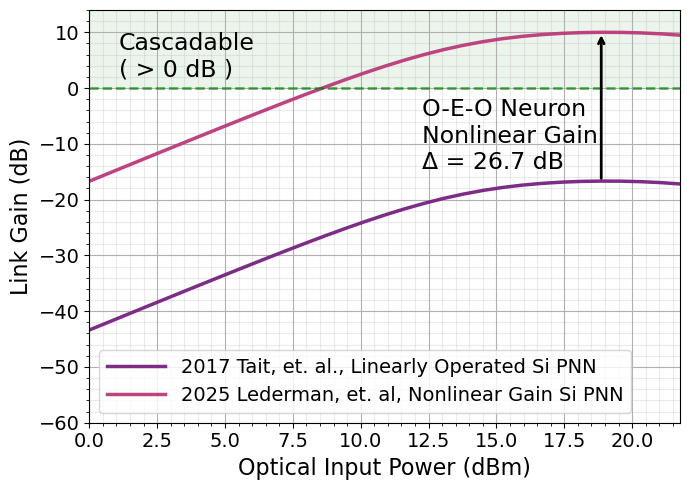

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

# --- Styling parameters ---
alpha_em = 0.95
lw_em = line_w

# --- Plot ---
ax.plot(
    Pin,
    G_EM_MRRModL,
    color=color[1],
    linewidth=lw_em,
    alpha=alpha_em,
    label='2017 Tait, et. al., Linearly Operated Si PNN',
    linestyle=line_EM
)

ax.plot(
    Pin,
    G_EM_MRRModNL,
    color=color[2],
    linewidth=lw_em,
    alpha=alpha_em,
    label='2025 Lederman, et. al, Nonlinear Gain Si PNN',
    linestyle=line_EM
)
# --- Find maxima ---
idx_lin = np.argmax(G_EM_MRRModL)
idx_nl  = np.argmax(G_EM_MRRModNL)

x_lin = Pin[idx_lin]
y_lin = G_EM_MRRModL[idx_lin]

x_nl  = Pin[idx_nl]
y_nl  = G_EM_MRRModNL[idx_nl]

delta_gain = y_nl - y_lin

# --- Draw vertical arrow ---
ax.annotate(
    '',
    xy=(x_lin, y_nl),        # arrow tip (top)
    xytext=(x_lin, y_lin),   # arrow base (bottom)
    arrowprops=dict(arrowstyle='->', linewidth=2, color='black')
)

# --- Add text next to arrow ---
ax.text(
    x_lin - 6.6,                   # slight horizontal offset
    (y_lin + y_nl)/2 - 5.3,  
    f'O-E-O Neuron \nNonlinear Gain\nΔ = {delta_gain:.1f} dB',
    fontsize=fs+1,
    verticalalignment='center'
)

arrowprops=dict(
    arrowstyle='-|>',
    linewidth=2.5,
    color='black',
    shrinkA=0,
    shrinkB=0
)

arrowprops=dict(
    arrowstyle='-|>',
    linewidth=3,
    color='black',
    shrinkA=0,
    shrinkB=0
)
delta_gain = y_nl - y_lin

ax.set_ylim(-60,14)

ax.axhline(y=0, color='green', linestyle='--', linewidth=1.8, alpha=0.7)
# --- Shade cascadable region (> 0 dB) ---
ax.axhspan(
    0, ax.get_ylim()[1],      # from 0 dB to top of axis
    facecolor='green',
    alpha=0.08,
    zorder=0
)

# Label the shaded region
ax.text(
    Pin_max * 0.05,           # left side
    ax.get_ylim()[1] - 4,     # near top
    'Cascadable\n( > 0 dB )',
    color='black',
    fontsize=fs+1,
    verticalalignment='top'
)

ax.set_ylabel('Link Gain (dB)', fontsize=fs)
ax.set_xlabel('Optical Input Power (dBm)', fontsize=fs)
ax.set_xlim(0, Pin_max)

ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.25)
ax.tick_params(axis='both', labelsize=fs-2)
ax.legend(frameon=True, fontsize=fs-2, handlelength=3, loc='best')
plt.tight_layout()
if isSaving:
    outputFile = 'RF_Analysis_Nonlinear.pdf'
    plt.savefig(outputFile, format='pdf', dpi=dpi_res, bbox_inches='tight')
plt.show()